1. Generate wavefront
   - fixed low-order aberration
   - random atmospheric phase screen

2. Measure wavefront slopes
   - geometric Shack-Hartmann model

3. Reconstruct wavefront
   - response matrix
   - least-squares modal reconstruction

4. Analyze limitations
   - noise sensitivity
   - lenslet sampling
   - modal truncation / fitting error

5. Demonstrate low-order AO correction
   - before/after residual RMS
   - optional PSF and Strehl ratio

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

import zernike
import phase_screen
import reconstruction

importlib.reload(zernike)
importlib.reload(phase_screen)
importlib.reload(reconstruction)

from zernike import (
    make_pupil_grid,
    zernike_named_modes,
    synthesize_wavefront,
)

from phase_screen import fourier_phase_screen

from reconstruction import (
    build_response_matrix,
    measure_slopes,
    reconstruct_wavefront,
    residual_wavefront,
    rms,
)

import shwfs_detector
importlib.reload(shwfs_detector)

from shwfs_detector import (
    build_detector_response_matrix,
    measure_centroid_shifts,
    reconstruct_from_centroid_shifts,
)

from reconstruction import (
    synthesize_from_coefficients,
)

In [2]:
def setup_pupil_and_modes(N=256, diameter=1.0):
    """
    Create pupil grid and low-order Zernike-like modes.
    """
    X, Y, rho, theta, mask, dx = make_pupil_grid(
        N=N,
        diameter=diameter,
    )

    modes = zernike_named_modes(
        rho,
        theta,
        mask,
        include_piston=False,
        normalized=True,
    )

    return X, Y, rho, theta, mask, dx, modes


def make_fixed_zernike_wavefront(modes, mask):
    """
    Deterministic low-order wavefront.

    This is useful for checking whether the reconstruction pipeline works.
    """
    true_coeffs = {
        "tip_x": 0.05,
        "tip_y": -0.03,
        "defocus": 0.25,
        "astig_45": -0.12,
        "astig_0": 0.08,
        "coma_x": 0.10,
        "coma_y": -0.07,
        "spherical": 0.04,
    }

    W_true = synthesize_wavefront(
        modes,
        true_coeffs,
        mask,
        remove_mean=True,
    )

    return W_true, true_coeffs


def make_random_atmospheric_wavefront(
    N,
    dx,
    diameter=1.0,
    r0=0.20,
    L0=25.0,
    seed=4,
    target_rms_rad=1.0,
):
    """
    Random atmospheric phase screen.

    Unit:
        radians of optical phase.

    Changing seed gives a different turbulence realization.
    """
    W_atm, _, _, _ = fourier_phase_screen(
        N=N,
        delta=dx,
        r0=r0,
        L0=L0,
        diameter=diameter,
        seed=seed,
        target_rms_rad=target_rms_rad,
    )

    return W_atm


def run_wfs_reconstruction(
    W_true,
    X,
    Y,
    mask,
    modes,
    n_lenslets=12,
    min_fill=0.5,
    noise_std=0.0,
    seed=1,
    rcond=1e-4,
):
    """
    Full geometric Shack-Hartmann WFS reconstruction pipeline.

    Steps:
        1. Measure local slopes
        2. Build response matrix
        3. Reconstruct modal coefficients
        4. Synthesize reconstructed wavefront
        5. Compute residual wavefront
    """
    centers, slopes = measure_slopes(
        W_true,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=min_fill,
        noise_std=noise_std,
        seed=seed,
    )

    A, names, _ = build_response_matrix(
        modes,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=min_fill,
    )

    coeffs, W_rec, residuals, rank, singular_values = reconstruct_wavefront(
        slopes,
        A,
        modes,
        names,
        mask,
        rcond=rcond,
    )

    res = residual_wavefront(W_true, W_rec, mask)

    return {
        "centers": centers,
        "slopes": slopes,
        "A": A,
        "names": names,
        "coeffs": coeffs,
        "W_rec": W_rec,
        "residual": res,
        "rank": rank,
        "singular_values": singular_values,
        "input_rms": rms(W_true, mask),
        "residual_rms": rms(res, mask),
    }

def run_wfs_reconstruction_detector(
    W_true,
    X,
    Y,
    mask,
    modes,
    n_lenslets=14,
    min_fill=0.5,
    pad_factor=4,
    photons=5000,
    read_noise_e=1.0,
    background_e=2.0,
    threshold_fraction=0.02,
    subtract_minimum=True,
    detector_window_size=24,
    calibration_amplitude=1e-3,
    rcond=1e-3,
    seed=1,
):
    """
    Detector-level SH-WFS reconstruction.

    This is more observation-like than the geometric slope model:
        phase -> lenslet spots -> noisy detector images
        -> centroid shifts -> calibrated modal reconstruction
    """
    A_det, names, centers, masks, reference = build_detector_response_matrix(
        modes,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=min_fill,
        pad_factor=pad_factor,
        threshold_fraction=threshold_fraction,
        subtract_minimum=subtract_minimum,
        detector_window_size=detector_window_size,
        calibration_amplitude=calibration_amplitude,
        differential=True,
    )

    _, shifts, diag = measure_centroid_shifts(
        W_true,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=min_fill,
        pad_factor=pad_factor,
        photons=photons,
        read_noise_e=read_noise_e,
        background_e=background_e,
        threshold_fraction=threshold_fraction,
        subtract_minimum=subtract_minimum,
        detector_window_size=detector_window_size,
        seed=seed,
        reference=reference,
        masks=masks,
        centers=centers,
        return_diagnostics=True,
    )

    coeffs, residuals, rank, singular_values = reconstruct_from_centroid_shifts(
        shifts,
        A_det,
        rcond=rcond,
    )

    W_rec = synthesize_from_coefficients(
        coeffs,
        modes,
        names,
        mask,
        remove_mean=True,
    )

    res = residual_wavefront(W_true, W_rec, mask)

    return {
        "A": A_det,
        "names": names,
        "centers": centers,
        "shifts": shifts,
        "diag": diag,
        "coeffs": coeffs,
        "W_rec": W_rec,
        "residual": res,
        "input_rms": rms(W_true, mask),
        "residual_rms": rms(res, mask),
        "rank": rank,
        "singular_values": singular_values,
        "condition_number": singular_values[0] / singular_values[-1],
        "n_valid_centroids": diag["n_valid"],
        "n_total_centroids": diag["n_total"],
    }

def plot_reconstruction_result(W_true, result, X, Y, title_prefix=""):
    """
    Plot wavefront, slopes, reconstruction, and residual.
    """
    W_rec = result["W_rec"]
    res = result["residual"]
    centers = result["centers"]
    slopes = result["slopes"]

    extent = [
        np.nanmin(X),
        np.nanmax(X),
        np.nanmin(Y),
        np.nanmax(Y),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(17, 4))

    im0 = axes[0].imshow(
        W_true,
        extent=extent,
        origin="lower",
    )
    axes[0].set_title(f"{title_prefix}True wavefront")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    axes[1].quiver(
        centers[:, 0],
        centers[:, 1],
        slopes[:, 0],
        slopes[:, 1],
    )
    axes[1].set_title("SH-WFS slopes")
    axes[1].set_aspect("equal")
    axes[1].set_xlim(extent[0], extent[1])
    axes[1].set_ylim(extent[2], extent[3])
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")

    im2 = axes[2].imshow(
        W_rec,
        extent=extent,
        origin="lower",
    )
    axes[2].set_title("Reconstructed")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("y")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    im3 = axes[3].imshow(
        res,
        extent=extent,
        origin="lower",
    )
    axes[3].set_title("Residual")
    axes[3].set_xlabel("x")
    axes[3].set_ylabel("y")
    plt.colorbar(im3, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()

In [3]:
N = 256
diameter = 1.0

X, Y, rho, theta, mask, dx, modes = setup_pupil_and_modes(
    N=N,
    diameter=diameter,
)

W_fixed, true_coeffs = make_fixed_zernike_wavefront(
    modes,
    mask,
)

W_atm = make_random_atmospheric_wavefront(
    N=N,
    dx=dx,
    diameter=diameter,
    r0=0.20,
    L0=25.0,
    seed=4,
    target_rms_rad=1.0,
)

print(f"Fixed Zernike-like wavefront RMS: {rms(W_fixed, mask):.4f}")
print(f"Random atmospheric wavefront RMS: {rms(W_atm, mask):.4f}")

Fixed Zernike-like wavefront RMS: 0.3210
Random atmospheric wavefront RMS: 0.9999


In [4]:
# ------------------------------------------------------------
# Detector-level SH-WFS calibration setup
# ------------------------------------------------------------

detector_cfg = dict(
    n_lenslets=14,
    min_fill=0.5,
    pad_factor=4,
    threshold_fraction=0.02,
    subtract_minimum=True,
    detector_window_size=24,
    calibration_amplitude=1e-3,
)

A_det, names_det, centers_det, masks_det, reference_det = build_detector_response_matrix(
    modes,
    mask,
    X,
    Y,
    n_lenslets=detector_cfg["n_lenslets"],
    min_fill=detector_cfg["min_fill"],
    pad_factor=detector_cfg["pad_factor"],
    threshold_fraction=detector_cfg["threshold_fraction"],
    subtract_minimum=detector_cfg["subtract_minimum"],
    detector_window_size=detector_cfg["detector_window_size"],
    calibration_amplitude=detector_cfg["calibration_amplitude"],
    differential=True,
)

u_det, s_det, vh_det = np.linalg.svd(A_det, full_matrices=False)

print("Detector-level response matrix")
print("--------------------------------")
print(f"A_det shape:          {A_det.shape}")
print(f"Number of modes:      {len(names_det)}")
print(f"Valid subapertures:   {len(centers_det)}")
print(f"Number of slopes:     {A_det.shape[0]}")
print(f"Rank:                 {np.linalg.matrix_rank(A_det)}")
print(f"Condition number:     {s_det[0] / s_det[-1]:.3e}")
print(f"Largest singular val: {s_det[0]:.3e}")
print(f"Smallest singular val:{s_det[-1]:.3e}")

Detector-level response matrix
--------------------------------
A_det shape:          (312, 10)
Number of modes:      10
Valid subapertures:   156
Number of slopes:     312
Rank:                 10
Condition number:     5.710e+00
Largest singular val: 1.038e+01
Smallest singular val:1.818e+00


In [5]:
# ------------------------------------------------------------
# Cached detector-level reconstruction helper
# ------------------------------------------------------------

def run_detector_cached(
    W_true,
    photons=20000,
    read_noise_e=1.0,
    background_e=1.0,
    seed=1,
    rcond=1e-3,
):
    """
    Detector-level SH-WFS reconstruction using a cached response matrix.

    This uses:
    phase -> lenslet spots -> noisy detector images -> centroid shifts -> modal reconstruction.
    """

    _, shifts, diag = measure_centroid_shifts(
        W_true,
        mask,
        X,
        Y,
        n_lenslets=detector_cfg["n_lenslets"],
        min_fill=detector_cfg["min_fill"],
        pad_factor=detector_cfg["pad_factor"],
        photons=photons,
        read_noise_e=read_noise_e,
        background_e=background_e,
        threshold_fraction=detector_cfg["threshold_fraction"],
        subtract_minimum=detector_cfg["subtract_minimum"],
        detector_window_size=detector_cfg["detector_window_size"],
        seed=seed,
        reference=reference_det,
        masks=masks_det,
        centers=centers_det,
        return_diagnostics=True,
    )

    coeffs, residuals, rank, singular_values = reconstruct_from_centroid_shifts(
        shifts,
        A_det,
        rcond=rcond,
    )

    W_rec = synthesize_from_coefficients(
        coeffs,
        modes,
        names_det,
        mask,
        remove_mean=True,
    )

    res = residual_wavefront(W_true, W_rec, mask)

    return {
        "W_rec": W_rec,
        "residual": res,
        "residual_rms": rms(res, mask),
        "input_rms": rms(W_true, mask),
        "coeffs": coeffs,
        "rank": rank,
        "singular_values": singular_values,
        "condition_number": singular_values[0] / singular_values[-1],
        "shifts": shifts,
        "diag": diag,
        "valid_fraction": diag["n_valid"] / diag["n_total"],
    }

In [6]:
# ------------------------------------------------------------
# Detector-level sanity check
# clean detector vs noisy detector
# ------------------------------------------------------------

# Use an already defined test wavefront if available.
# Otherwise fall back to a moderate atmospheric-like phase screen.
if "W_fixed" in globals():
    W_test = W_fixed
    test_name = "fixed low-order Zernike wavefront"
elif "W_atm" in globals():
    W_test = W_atm
    test_name = "atmospheric phase screen"
else:
    raise RuntimeError("Neither W_fixed nor W_atm is defined. Please run the earlier wavefront-generation cells first.")

# Clean detector-level reconstruction:
# no photon noise, no read noise, no background
result_det_clean = run_detector_cached(
    W_test,
    photons=None,
    read_noise_e=0.0,
    background_e=0.0,
    seed=1,
    rcond=1e-3,
)

# Noisy detector-level reconstruction:
# realistic finite photon budget + read noise + background
result_det_noisy = run_detector_cached(
    W_test,
    photons=20000,
    read_noise_e=1.0,
    background_e=1.0,
    seed=1,
    rcond=1e-3,
)

print(f"Detector-level sanity check using: {test_name}")
print("------------------------------------------------")
print("Input wavefront")
print(f"Input RMS:              {result_det_clean['input_rms']:.4e} rad")

print("\nClean detector reconstruction")
print(f"Residual RMS:           {result_det_clean['residual_rms']:.4e} rad")
print(f"Residual / input RMS:   {result_det_clean['residual_rms'] / result_det_clean['input_rms']:.4f}")
print(f"Valid centroid fraction:{result_det_clean['valid_fraction']:.3f}")
print(f"Rank:                   {result_det_clean['rank']}")

print("\nNoisy detector reconstruction")
print(f"Residual RMS:           {result_det_noisy['residual_rms']:.4e} rad")
print(f"Residual / input RMS:   {result_det_noisy['residual_rms'] / result_det_noisy['input_rms']:.4f}")
print(f"Valid centroid fraction:{result_det_noisy['valid_fraction']:.3f}")
print(f"Rank:                   {result_det_noisy['rank']}")

Detector-level sanity check using: fixed low-order Zernike wavefront
------------------------------------------------
Input wavefront
Input RMS:              3.2096e-01 rad

Clean detector reconstruction
Residual RMS:           4.5229e-02 rad
Residual / input RMS:   0.1409
Valid centroid fraction:1.000
Rank:                   10

Noisy detector reconstruction
Residual RMS:           6.6615e-02 rad
Residual / input RMS:   0.2076
Valid centroid fraction:1.000
Rank:                   10


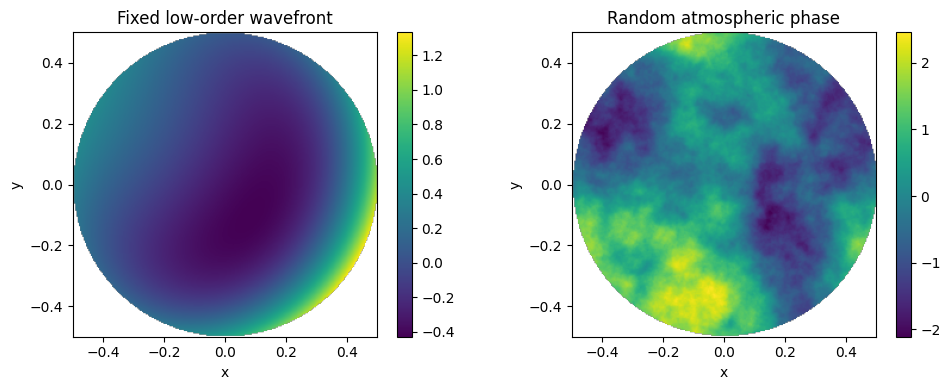

In [7]:
extent = [
    np.nanmin(X),
    np.nanmax(X),
    np.nanmin(Y),
    np.nanmax(Y),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(
    W_fixed,
    extent=extent,
    origin="lower",
)
axes[0].set_title("Fixed low-order wavefront")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(
    W_atm,
    extent=extent,
    origin="lower",
)
axes[1].set_title("Random atmospheric phase")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

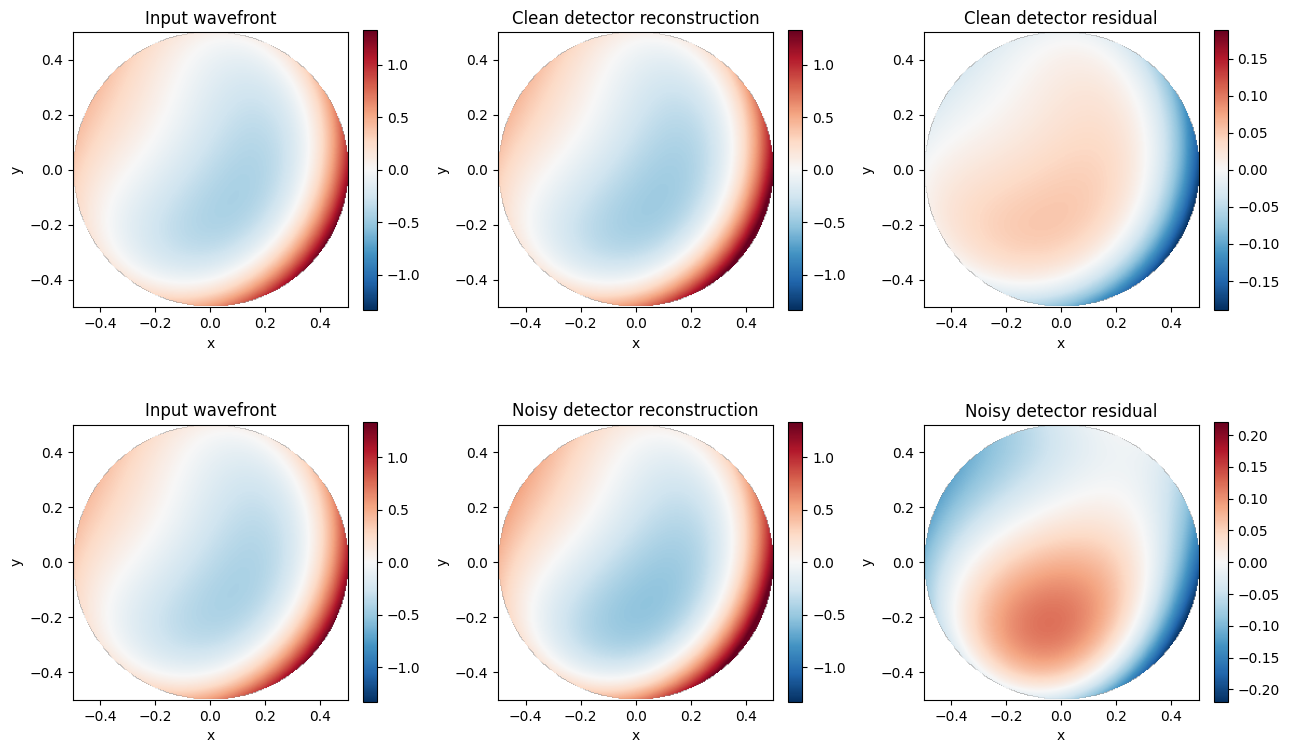

In [8]:
# ------------------------------------------------------------
# Visualize clean vs noisy detector-level reconstruction
# ------------------------------------------------------------

W_rec_clean = result_det_clean["W_rec"]
W_res_clean = result_det_clean["residual"]

W_rec_noisy = result_det_noisy["W_rec"]
W_res_noisy = result_det_noisy["residual"]

vmax = np.nanmax(np.abs(W_test[mask]))

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

items = [
    (W_test, "Input wavefront", vmax),
    (W_rec_clean, "Clean detector reconstruction", vmax),
    (W_res_clean, "Clean detector residual", np.nanmax(np.abs(W_res_clean[mask]))),
    (W_test, "Input wavefront", vmax),
    (W_rec_noisy, "Noisy detector reconstruction", vmax),
    (W_res_noisy, "Noisy detector residual", np.nanmax(np.abs(W_res_noisy[mask]))),
]

for ax, (img, title, scale) in zip(axes.ravel(), items):
    im = ax.imshow(
        np.where(mask, img, np.nan),
        extent=extent,
        origin="lower",
        cmap="RdBu_r",
        vmin=-scale,
        vmax=scale,
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

### Detector-level sanity check

This test separates the intrinsic detector-model reconstruction error from noise propagation.

- The clean detector case uses the same centroiding pipeline but disables photon noise, read noise, and background.
- The remaining residual is therefore mainly caused by finite detector sampling, finite detector window size, centroid bias, and modal truncation.
- The noisy detector case includes finite photon statistics, read noise, and background. The increase in residual RMS quantifies the noise propagation from detector images to centroid shifts and finally to modal wavefront reconstruction.

This is more realistic than the ideal geometric SH-WFS model, where local wavefront slopes are measured directly without spot formation, detector sampling, or centroid noise.

In [9]:
#Sanity check
result_fixed = run_wfs_reconstruction(
    W_fixed,
    X,
    Y,
    mask,
    modes,
    n_lenslets=12,
    noise_std=0.0,
    seed=1,
)

print("Estimated coefficients")
print("----------------------")

for name, coeff in zip(result_fixed["names"], result_fixed["coeffs"]):
    true_value = true_coeffs.get(name, 0.0)
    print(f"{name:12s}: true = {true_value:+.4f}, estimated = {coeff:+.4f}")

print()
print(f"Input RMS:    {result_fixed['input_rms']:.4e}")
print(f"Residual RMS: {result_fixed['residual_rms']:.4e}")
print(f"Rank:         {result_fixed['rank']}")

Estimated coefficients
----------------------
tip_x       : true = +0.0500, estimated = +0.0500
tip_y       : true = -0.0300, estimated = -0.0300
defocus     : true = +0.2500, estimated = +0.2500
astig_45    : true = -0.1200, estimated = -0.1200
astig_0     : true = +0.0800, estimated = +0.0800
coma_x      : true = +0.1000, estimated = +0.1000
coma_y      : true = -0.0700, estimated = -0.0700
trefoil_x   : true = +0.0000, estimated = +0.0000
trefoil_y   : true = +0.0000, estimated = -0.0000
spherical   : true = +0.0400, estimated = +0.0400

Input RMS:    3.2096e-01
Residual RMS: 4.5609e-05
Rank:         10


In [10]:
# ------------------------------------------------------------
# Detector diagnostics
# flux, centroid shift, valid centroid map
# ------------------------------------------------------------

diag = result_det_noisy["diag"]
shifts = result_det_noisy["shifts"]

fluxes = diag["fluxes"]
valid = diag["valid"]
shift_norm = np.linalg.norm(shifts, axis=1)

print("Detector diagnostics")
print("--------------------")
print(f"Number of subapertures:     {diag['n_total']}")
print(f"Valid centroids:            {diag['n_valid']}")
print(f"Valid centroid fraction:    {diag['n_valid'] / diag['n_total']:.3f}")
print(f"Median flux:                {np.nanmedian(fluxes):.2f} e-")
print(f"Min flux:                   {np.nanmin(fluxes):.2f} e-")
print(f"Max flux:                   {np.nanmax(fluxes):.2f} e-")
print(f"Median centroid shift:      {np.nanmedian(shift_norm):.3f} px")
print(f"Max centroid shift:         {np.nanmax(shift_norm):.3f} px")

Detector diagnostics
--------------------
Number of subapertures:     156
Valid centroids:            156
Valid centroid fraction:    1.000
Median flux:                19402.89 e-
Min flux:                   19096.69 e-
Max flux:                   19768.01 e-
Median centroid shift:      0.092 px
Max centroid shift:         0.471 px


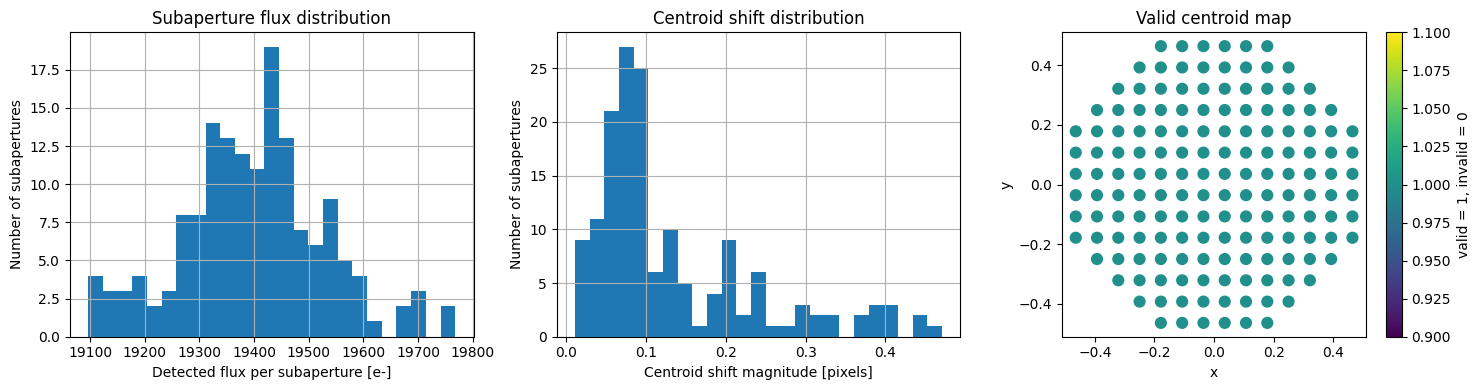

In [11]:
# ------------------------------------------------------------
# Plot detector diagnostics
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Flux distribution
axes[0].hist(fluxes[np.isfinite(fluxes)], bins=25)
axes[0].set_xlabel("Detected flux per subaperture [e-]")
axes[0].set_ylabel("Number of subapertures")
axes[0].set_title("Subaperture flux distribution")
axes[0].grid(True)

# Centroid shift distribution
axes[1].hist(shift_norm[np.isfinite(shift_norm)], bins=25)
axes[1].set_xlabel("Centroid shift magnitude [pixels]")
axes[1].set_ylabel("Number of subapertures")
axes[1].set_title("Centroid shift distribution")
axes[1].grid(True)

# Valid centroid map
sc = axes[2].scatter(
    centers_det[:, 0],
    centers_det[:, 1],
    c=valid.astype(float),
    s=60,
)
axes[2].set_aspect("equal")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_title("Valid centroid map")
plt.colorbar(sc, ax=axes[2], label="valid = 1, invalid = 0")

plt.tight_layout()
plt.show()

### Detector diagnostics

The detector diagnostics check whether the centroid measurements are physically meaningful before they are used for wavefront reconstruction.

- The flux distribution shows how many photo-electrons are detected in each valid subaperture.
- The centroid shift distribution shows whether the spot displacements remain within a reasonable dynamic range.
- The valid centroid map shows which lenslets provide usable centroid measurements.

A low valid fraction would indicate centroid failure, usually caused by insufficient flux, excessive noise, spot clipping, thresholding problems, or very large spot displacements. In that case, reconstruction quality cannot be interpreted only from the modal residual RMS; the detector measurement itself is already failing.

In [12]:
# ------------------------------------------------------------
# Inspect detector spot images
# ------------------------------------------------------------

# Generate detector spots for the same test wavefront used above.
# Here we use the noisy case, because this is closer to detector-level measurement.

centroids_demo, shifts_demo, spots_demo, diag_demo = measure_centroid_shifts(
    W_test,
    mask,
    X,
    Y,
    n_lenslets=detector_cfg["n_lenslets"],
    min_fill=detector_cfg["min_fill"],
    pad_factor=detector_cfg["pad_factor"],
    photons=20000,
    read_noise_e=1.0,
    background_e=1.0,
    threshold_fraction=detector_cfg["threshold_fraction"],
    subtract_minimum=detector_cfg["subtract_minimum"],
    detector_window_size=detector_cfg["detector_window_size"],
    seed=5,
    reference=reference_det,
    masks=masks_det,
    centers=centers_det,
    return_spots=True,
    return_diagnostics=True,
)

print("Spot image inspection")
print("---------------------")
print(f"Number of spot images: {len(spots_demo)}")
print(f"Spot image shape:      {spots_demo[0].shape}")
print(f"Valid centroids:       {diag_demo['n_valid']} / {diag_demo['n_total']}")

Spot image inspection
---------------------
Number of spot images: 156
Spot image shape:      (24, 24)
Valid centroids:       156 / 156


In [13]:
# ------------------------------------------------------------
# Select representative lenslets
# ------------------------------------------------------------

# Central lenslet: closest to pupil center
idx_center = np.argmin(np.sum(centers_det**2, axis=1))

# Edge lenslet: largest distance from pupil center
idx_edge = np.argmax(np.sum(centers_det**2, axis=1))

# Largest centroid shift
shift_norm_demo = np.linalg.norm(shifts_demo, axis=1)
idx_large_shift = np.nanargmax(shift_norm_demo)

print("Selected lenslets")
print("-----------------")
print(f"Central lenslet index:      {idx_center}")
print(f"Edge lenslet index:         {idx_edge}")
print(f"Largest-shift lenslet index:{idx_large_shift}")
print()
print(f"Central shift:      {shift_norm_demo[idx_center]:.3f} px")
print(f"Edge shift:         {shift_norm_demo[idx_edge]:.3f} px")
print(f"Largest shift:      {shift_norm_demo[idx_large_shift]:.3f} px")

Selected lenslets
-----------------
Central lenslet index:      85
Edge lenslet index:         0
Largest-shift lenslet index:142

Central shift:      0.078 px
Edge shift:         0.057 px
Largest shift:      0.457 px


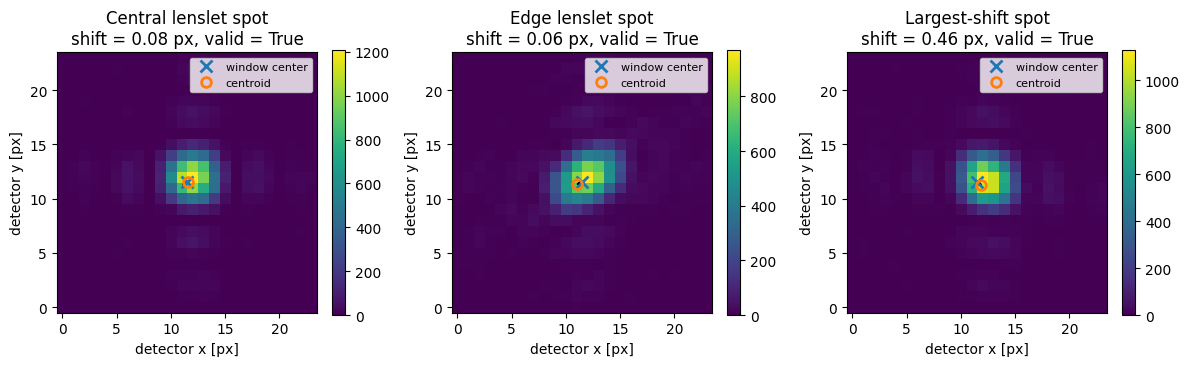

In [14]:
# ------------------------------------------------------------
# Plot representative detector spot images
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

spot_items = [
    (idx_center, "Central lenslet spot"),
    (idx_edge, "Edge lenslet spot"),
    (idx_large_shift, "Largest-shift spot"),
]

for ax, (idx, title) in zip(axes, spot_items):
    spot = spots_demo[idx]

    im = ax.imshow(
        spot,
        origin="lower",
        interpolation="nearest",
    )

    # Pixel coordinates run from 0 to N-1.
    # For a 24 x 24 window, the geometric center is 11.5, not 12.
    cy, cx = (np.array(spot.shape) - 1) / 2.0

    # Mark detector window center:
    # this is the nominal spot position for zero local wavefront slope.
    ax.plot(
        cx,
        cy,
        "x",
        markersize=8,
        markeredgewidth=2,
        label="window center",
    )

    # Mark measured centroid, if valid.
    #
    # IMPORTANT:
    # In this notebook, centroids_demo[idx] appears to store the centroid shift
    # relative to the window center, not the absolute centroid position.
    #
    # Therefore:
    #     centroid_position = window_center + centroid_shift
    #
    # If your centroids_demo is later changed to store absolute detector-window
    # positions, then remove the "+ cx" and "+ cy" below.
    if np.all(np.isfinite(centroids_demo[idx])):
        dx, dy = centroids_demo[idx]

        centroid_x = cx + dx
        centroid_y = cy + dy

        ax.plot(
            centroid_x,
            centroid_y,
            "o",
            markersize=7,
            markeredgewidth=2,
            fillstyle="none",
            label="centroid",
        )

        # Optional: draw an arrow from reference center to measured centroid.
        ax.arrow(
            cx,
            cy,
            dx,
            dy,
            head_width=0.35,
            head_length=0.45,
            length_includes_head=True,
            linewidth=1.2,
        )

    ax.set_title(
        f"{title}\n"
        f"shift = {shift_norm_demo[idx]:.2f} px, "
        f"valid = {diag_demo['valid'][idx]}"
    )
    ax.set_xlabel("detector x [px]")
    ax.set_ylabel("detector y [px]")
    ax.legend(fontsize=8, loc="upper right")

    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

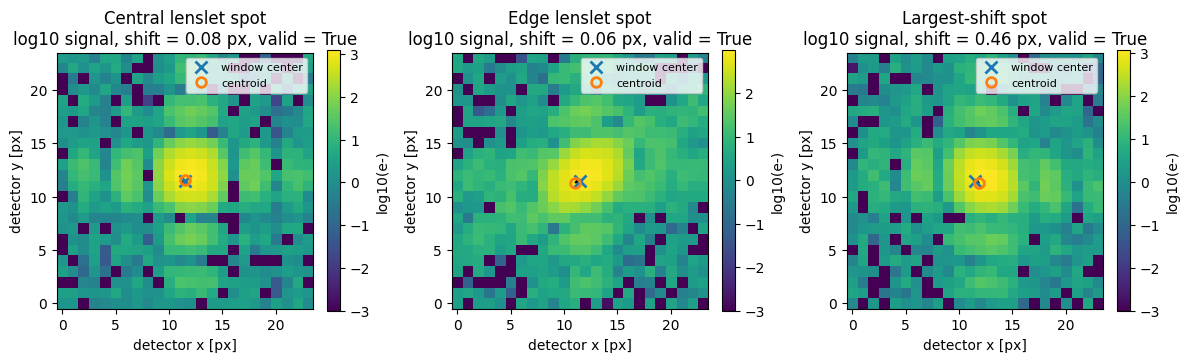

In [15]:
# ------------------------------------------------------------
# Log-display version of detector spots
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (idx, title) in zip(axes, spot_items):
    spot = spots_demo[idx]

    # Avoid log(0)
    spot_log = np.log10(np.maximum(spot, 1e-3))

    im = ax.imshow(
        spot_log,
        origin="lower",
        interpolation="nearest",
    )

    # Pixel coordinates run from 0 to N-1.
    # For a 24 x 24 window, the geometric center is 11.5, not 12.
    cy, cx = (np.array(spot.shape) - 1) / 2.0

    # Mark detector window center.
    ax.plot(
        cx,
        cy,
        "x",
        markersize=8,
        markeredgewidth=2,
        label="window center",
    )

    # Mark measured centroid, if valid.
    #
    # IMPORTANT:
    # centroids_demo[idx] stores centroid shift relative to the window center,
    # not absolute detector-window coordinates.
    if np.all(np.isfinite(centroids_demo[idx])):
        dx, dy = centroids_demo[idx]

        centroid_x = cx + dx
        centroid_y = cy + dy

        ax.plot(
            centroid_x,
            centroid_y,
            "o",
            markersize=7,
            markeredgewidth=2,
            fillstyle="none",
            label="centroid",
        )

        # Optional: draw an arrow from reference center to measured centroid.
        ax.arrow(
            cx,
            cy,
            dx,
            dy,
            head_width=0.35,
            head_length=0.45,
            length_includes_head=True,
            linewidth=1.2,
        )

    ax.set_title(
        f"{title}\n"
        f"log10 signal, "
        f"shift = {shift_norm_demo[idx]:.2f} px, "
        f"valid = {diag_demo['valid'][idx]}"
    )
    ax.set_xlabel("detector x [px]")
    ax.set_ylabel("detector y [px]")
    ax.legend(fontsize=8, loc="upper right")

    plt.colorbar(im, ax=ax, fraction=0.046, label="log10(e-)")

plt.tight_layout()
plt.show()

### Detector spot image inspection

This section visualizes the actual detector images used for centroiding.

The plotted spots show how local wavefront tilt is converted into a displacement of the focal spot inside each lenslet detector window. The measured centroid is marked on top of the detector image.

This is an important detector-level diagnostic because reconstruction errors can originate before the modal inversion step:

- spot clipping due to a finite detector window,
- poor centroiding due to photon noise or read noise,
- threshold-induced centroid bias,
- large spot displacement outside the linear response regime,
- lower signal quality in partially illuminated edge subapertures.

Therefore, inspecting the spot images helps verify that the SH-WFS measurement itself is physically meaningful before interpreting the reconstructed wavefront residual.

In [16]:
# ------------------------------------------------------------
# Lenslet-number scan with fixed total photon budget
# ------------------------------------------------------------

def detector_lenslet_scan_fixed_total_photons(
    W_true,
    lenslet_values,
    total_photons_per_frame=3e5,
    read_noise_e=1.0,
    background_e=1.0,
    rcond=1e-3,
    seed=10,
):
    """
    Scan the number of SH-WFS lenslets under a fixed total photon budget.

    For each lenslet number:
    - build a detector-level response matrix,
    - distribute the total photons over valid subapertures,
    - measure noisy centroid shifts,
    - reconstruct the wavefront,
    - record residual RMS and detector diagnostics.
    """

    residual_rms_values = []
    rank_values = []
    cond_values = []
    n_valid_values = []
    photons_per_subap_values = []
    valid_fraction_values = []

    for n_lens in lenslet_values:

        cfg = detector_cfg.copy()
        cfg["n_lenslets"] = int(n_lens)

        A_tmp, names_tmp, centers_tmp, masks_tmp, ref_tmp = build_detector_response_matrix(
            modes,
            mask,
            X,
            Y,
            n_lenslets=cfg["n_lenslets"],
            min_fill=cfg["min_fill"],
            pad_factor=cfg["pad_factor"],
            threshold_fraction=cfg["threshold_fraction"],
            subtract_minimum=cfg["subtract_minimum"],
            detector_window_size=cfg["detector_window_size"],
            calibration_amplitude=cfg["calibration_amplitude"],
            differential=True,
        )

        n_valid_subap = len(centers_tmp)

        if n_valid_subap == 0:
            residual_rms_values.append(np.nan)
            rank_values.append(0)
            cond_values.append(np.nan)
            n_valid_values.append(0)
            photons_per_subap_values.append(np.nan)
            valid_fraction_values.append(0.0)
            continue

        photons_per_subap = int(max(total_photons_per_frame / n_valid_subap, 1))

        _, shifts_tmp, diag_tmp = measure_centroid_shifts(
            W_true,
            mask,
            X,
            Y,
            n_lenslets=cfg["n_lenslets"],
            min_fill=cfg["min_fill"],
            pad_factor=cfg["pad_factor"],
            photons=photons_per_subap,
            read_noise_e=read_noise_e,
            background_e=background_e,
            threshold_fraction=cfg["threshold_fraction"],
            subtract_minimum=cfg["subtract_minimum"],
            detector_window_size=cfg["detector_window_size"],
            seed=seed,
            reference=ref_tmp,
            masks=masks_tmp,
            centers=centers_tmp,
            return_diagnostics=True,
        )

        coeffs_tmp, residuals_tmp, rank_tmp, singular_values_tmp = reconstruct_from_centroid_shifts(
            shifts_tmp,
            A_tmp,
            rcond=rcond,
        )

        W_rec_tmp = synthesize_from_coefficients(
            coeffs_tmp,
            modes,
            names_tmp,
            mask,
            remove_mean=True,
        )

        res_tmp = residual_wavefront(W_true, W_rec_tmp, mask)

        residual_rms_values.append(rms(res_tmp, mask))
        rank_values.append(rank_tmp)
        cond_values.append(singular_values_tmp[0] / singular_values_tmp[-1])
        n_valid_values.append(n_valid_subap)
        photons_per_subap_values.append(photons_per_subap)
        valid_fraction_values.append(diag_tmp["n_valid"] / diag_tmp["n_total"])

    return {
        "lenslets": np.array(lenslet_values),
        "residual_rms": np.array(residual_rms_values),
        "rank": np.array(rank_values),
        "condition_number": np.array(cond_values),
        "n_valid_subapertures": np.array(n_valid_values),
        "photons_per_subaperture": np.array(photons_per_subap_values),
        "valid_fraction": np.array(valid_fraction_values),
    }

In [17]:
# ------------------------------------------------------------
# Run detector-level lenslet scan
# ------------------------------------------------------------

if "W_atm" in globals():
    W_scan = W_atm
    scan_name = "atmospheric phase screen"
else:
    W_scan = W_test
    scan_name = "test wavefront"

lenslet_values = np.array([4, 5, 6, 8, 10, 12, 14, 16, 20])

scan_det = detector_lenslet_scan_fixed_total_photons(
    W_scan,
    lenslet_values=lenslet_values,
    total_photons_per_frame=3e5,
    read_noise_e=1.0,
    background_e=1.0,
    rcond=1e-3,
    seed=10,
)

print(f"Detector lenslet scan using: {scan_name}")
print("------------------------------------------------")
for i, n_lens in enumerate(scan_det["lenslets"]):
    print(
        f"n_lenslets={n_lens:2d} | "
        f"residual RMS={scan_det['residual_rms'][i]:.4e} rad | "
        f"photons/subap={scan_det['photons_per_subaperture'][i]:7.0f} | "
        f"valid subap={scan_det['n_valid_subapertures'][i]:3d} | "
        f"valid frac={scan_det['valid_fraction'][i]:.3f} | "
        f"rank={scan_det['rank'][i]:2d}"
    )

Detector lenslet scan using: atmospheric phase screen
------------------------------------------------
n_lenslets= 4 | residual RMS=6.1954e-01 rad | photons/subap=  25000 | valid subap= 12 | valid frac=1.000 | rank=10
n_lenslets= 5 | residual RMS=6.6061e-01 rad | photons/subap=  14285 | valid subap= 21 | valid frac=1.000 | rank=10
n_lenslets= 6 | residual RMS=6.6398e-01 rad | photons/subap=   9375 | valid subap= 32 | valid frac=1.000 | rank=10
n_lenslets= 8 | residual RMS=6.6057e-01 rad | photons/subap=   5769 | valid subap= 52 | valid frac=1.000 | rank=10
n_lenslets=10 | residual RMS=6.4747e-01 rad | photons/subap=   3750 | valid subap= 80 | valid frac=1.000 | rank=10
n_lenslets=12 | residual RMS=7.3238e-01 rad | photons/subap=   2678 | valid subap=112 | valid frac=1.000 | rank=10
n_lenslets=14 | residual RMS=9.1520e-01 rad | photons/subap=   1923 | valid subap=156 | valid frac=1.000 | rank=10
n_lenslets=16 | residual RMS=1.3512e+00 rad | photons/subap=   1442 | valid subap=208 | vali

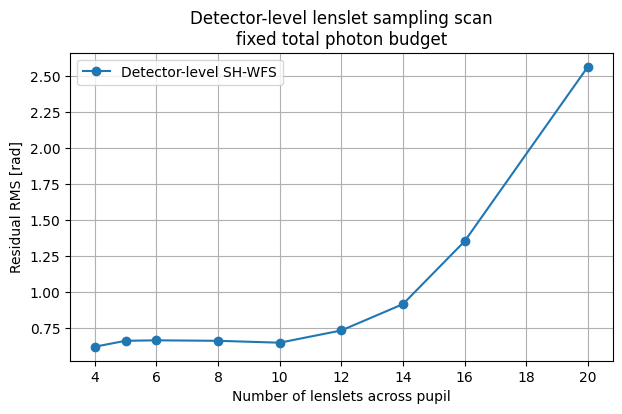

In [18]:
# ------------------------------------------------------------
# Plot residual RMS vs lenslet number
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.plot(
    scan_det["lenslets"],
    scan_det["residual_rms"],
    marker="o",
    label="Detector-level SH-WFS",
)

plt.xlabel("Number of lenslets across pupil")
plt.ylabel("Residual RMS [rad]")
plt.title("Detector-level lenslet sampling scan\nfixed total photon budget")
plt.grid(True)
plt.legend()
plt.show()

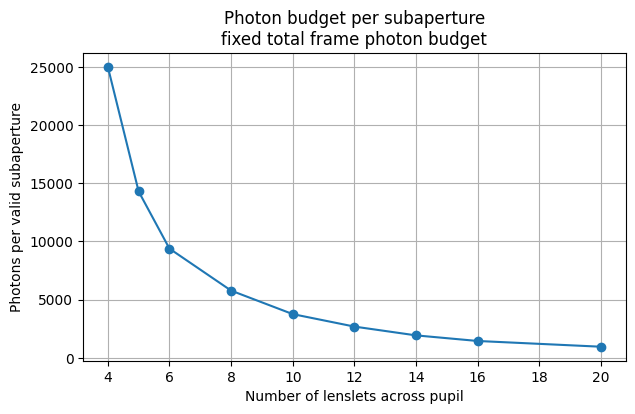

In [19]:
# ------------------------------------------------------------
# Plot photon budget per subaperture
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.plot(
    scan_det["lenslets"],
    scan_det["photons_per_subaperture"],
    marker="o",
)

plt.xlabel("Number of lenslets across pupil")
plt.ylabel("Photons per valid subaperture")
plt.title("Photon budget per subaperture\nfixed total frame photon budget")
plt.grid(True)
plt.show()

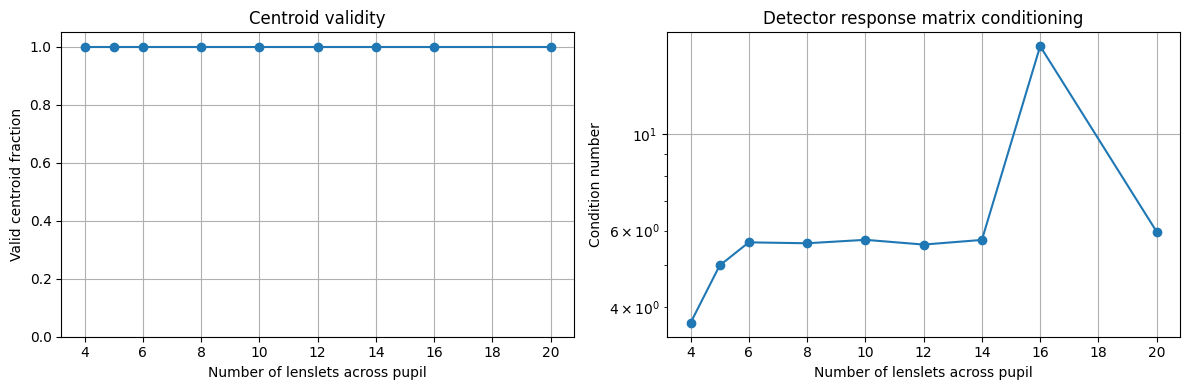

In [20]:
# ------------------------------------------------------------
# Plot detector validity and matrix conditioning
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    scan_det["lenslets"],
    scan_det["valid_fraction"],
    marker="o",
)
axes[0].set_xlabel("Number of lenslets across pupil")
axes[0].set_ylabel("Valid centroid fraction")
axes[0].set_title("Centroid validity")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True)

axes[1].semilogy(
    scan_det["lenslets"],
    scan_det["condition_number"],
    marker="o",
)
axes[1].set_xlabel("Number of lenslets across pupil")
axes[1].set_ylabel("Condition number")
axes[1].set_title("Detector response matrix conditioning")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Lenslet-number scan with fixed total photon budget

This test is more detector realistic than assigning the same photon number to every subaperture.

For a fixed total photon budget, increasing the number of lenslets improves spatial sampling of the wavefront, but it also reduces the number of photons available per subaperture. Therefore, the centroid measurements become noisier at high lenslet counts.

The resulting residual RMS is controlled by a trade-off between:

- spatial sampling error at low lenslet counts,
- centroid noise at high lenslet counts,
- partially illuminated edge subapertures,
- the conditioning of the detector-level response matrix,
- and modal truncation of the reconstructed wavefront.

A minimum in the residual-RMS curve indicates an approximate optimal sampling regime for the chosen wavefront, detector settings, and photon budget.

In [21]:
# ------------------------------------------------------------
# Detector window-size scan
# ------------------------------------------------------------

def detector_window_size_scan(
    W_true,
    window_values,
    photons=20000,
    read_noise_e=1.0,
    background_e=1.0,
    rcond=1e-3,
    seed=20,
):
    """
    Scan detector window size for the same lenslet configuration.

    This tests whether finite detector windows cause:
    - spot clipping,
    - biased centroid measurements,
    - reduced valid centroid fraction,
    - degraded wavefront reconstruction.
    """

    residual_rms_values = []
    valid_fraction_values = []
    median_shift_values = []
    max_shift_values = []
    cond_values = []
    rank_values = []

    for win in window_values:

        cfg = detector_cfg.copy()
        cfg["detector_window_size"] = int(win)

        A_tmp, names_tmp, centers_tmp, masks_tmp, ref_tmp = build_detector_response_matrix(
            modes,
            mask,
            X,
            Y,
            n_lenslets=cfg["n_lenslets"],
            min_fill=cfg["min_fill"],
            pad_factor=cfg["pad_factor"],
            threshold_fraction=cfg["threshold_fraction"],
            subtract_minimum=cfg["subtract_minimum"],
            detector_window_size=cfg["detector_window_size"],
            calibration_amplitude=cfg["calibration_amplitude"],
            differential=True,
        )

        _, shifts_tmp, diag_tmp = measure_centroid_shifts(
            W_true,
            mask,
            X,
            Y,
            n_lenslets=cfg["n_lenslets"],
            min_fill=cfg["min_fill"],
            pad_factor=cfg["pad_factor"],
            photons=photons,
            read_noise_e=read_noise_e,
            background_e=background_e,
            threshold_fraction=cfg["threshold_fraction"],
            subtract_minimum=cfg["subtract_minimum"],
            detector_window_size=cfg["detector_window_size"],
            seed=seed,
            reference=ref_tmp,
            masks=masks_tmp,
            centers=centers_tmp,
            return_diagnostics=True,
        )

        coeffs_tmp, residuals_tmp, rank_tmp, singular_values_tmp = reconstruct_from_centroid_shifts(
            shifts_tmp,
            A_tmp,
            rcond=rcond,
        )

        W_rec_tmp = synthesize_from_coefficients(
            coeffs_tmp,
            modes,
            names_tmp,
            mask,
            remove_mean=True,
        )

        res_tmp = residual_wavefront(W_true, W_rec_tmp, mask)

        shift_norm_tmp = np.linalg.norm(shifts_tmp, axis=1)

        residual_rms_values.append(rms(res_tmp, mask))
        valid_fraction_values.append(diag_tmp["n_valid"] / diag_tmp["n_total"])
        median_shift_values.append(np.nanmedian(shift_norm_tmp))
        max_shift_values.append(np.nanmax(shift_norm_tmp))
        cond_values.append(singular_values_tmp[0] / singular_values_tmp[-1])
        rank_values.append(rank_tmp)

    return {
        "window_size": np.array(window_values),
        "residual_rms": np.array(residual_rms_values),
        "valid_fraction": np.array(valid_fraction_values),
        "median_shift": np.array(median_shift_values),
        "max_shift": np.array(max_shift_values),
        "condition_number": np.array(cond_values),
        "rank": np.array(rank_values),
    }

In [22]:
# ------------------------------------------------------------
# Run detector window-size scan
# ------------------------------------------------------------

if "W_atm" in globals():
    W_window = W_atm
    window_test_name = "atmospheric phase screen"
else:
    W_window = W_test
    window_test_name = "test wavefront"

window_values = np.array([8, 12, 16, 20, 24, 32, 40, 48])

scan_window = detector_window_size_scan(
    W_window,
    window_values=window_values,
    photons=20000,
    read_noise_e=1.0,
    background_e=1.0,
    rcond=1e-3,
    seed=20,
)

print(f"Detector window-size scan using: {window_test_name}")
print("------------------------------------------------")
for i, win in enumerate(scan_window["window_size"]):
    print(
        f"window={win:2d} px | "
        f"residual RMS={scan_window['residual_rms'][i]:.4e} rad | "
        f"valid frac={scan_window['valid_fraction'][i]:.3f} | "
        f"median shift={scan_window['median_shift'][i]:.3f} px | "
        f"max shift={scan_window['max_shift'][i]:.3f} px | "
        f"rank={scan_window['rank'][i]:2d}"
    )

Detector window-size scan using: atmospheric phase screen
------------------------------------------------
window= 8 px | residual RMS=6.4023e-01 rad | valid frac=1.000 | median shift=0.429 px | max shift=1.170 px | rank=10
window=12 px | residual RMS=6.4436e-01 rad | valid frac=1.000 | median shift=0.380 px | max shift=0.960 px | rank=10
window=16 px | residual RMS=6.3420e-01 rad | valid frac=1.000 | median shift=0.426 px | max shift=1.039 px | rank=10
window=20 px | residual RMS=6.4691e-01 rad | valid frac=1.000 | median shift=0.412 px | max shift=1.038 px | rank=10
window=24 px | residual RMS=6.3697e-01 rad | valid frac=1.000 | median shift=0.424 px | max shift=0.993 px | rank=10
window=32 px | residual RMS=6.3812e-01 rad | valid frac=1.000 | median shift=0.425 px | max shift=1.024 px | rank=10
window=40 px | residual RMS=6.4145e-01 rad | valid frac=1.000 | median shift=0.425 px | max shift=1.063 px | rank=10
window=48 px | residual RMS=6.4099e-01 rad | valid frac=1.000 | median shi

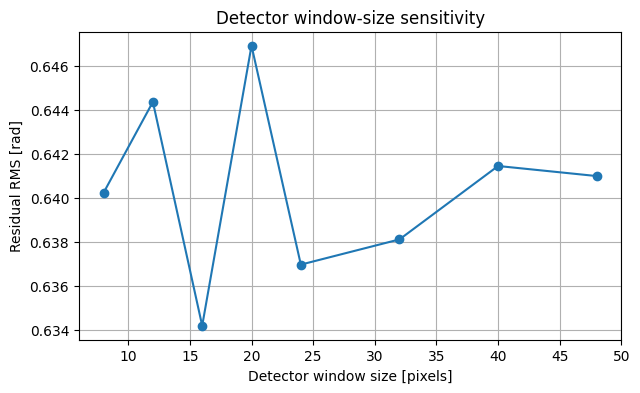

In [23]:
# ------------------------------------------------------------
# Plot residual RMS vs detector window size
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.plot(
    scan_window["window_size"],
    scan_window["residual_rms"],
    marker="o",
)

plt.xlabel("Detector window size [pixels]")
plt.ylabel("Residual RMS [rad]")
plt.title("Detector window-size sensitivity")
plt.grid(True)
plt.show()

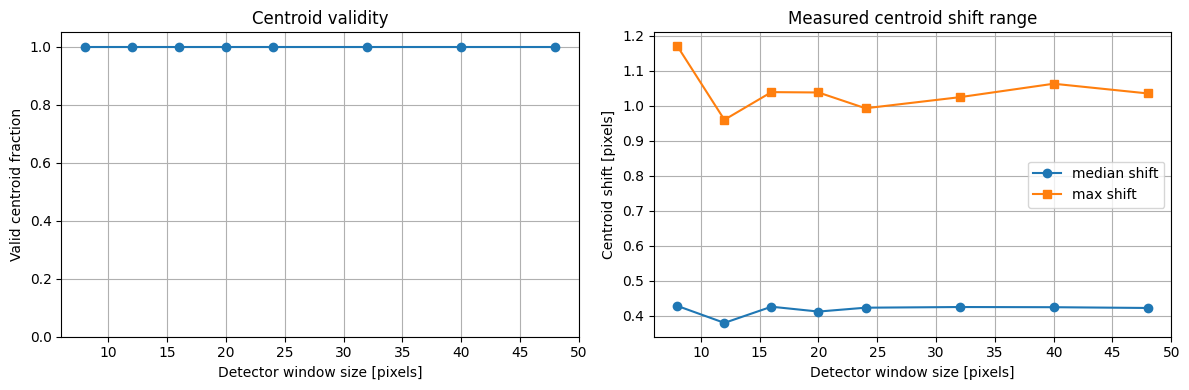

In [24]:
# ------------------------------------------------------------
# Plot centroid validity and shift range
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    scan_window["window_size"],
    scan_window["valid_fraction"],
    marker="o",
)
axes[0].set_xlabel("Detector window size [pixels]")
axes[0].set_ylabel("Valid centroid fraction")
axes[0].set_title("Centroid validity")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True)

axes[1].plot(
    scan_window["window_size"],
    scan_window["median_shift"],
    marker="o",
    label="median shift",
)
axes[1].plot(
    scan_window["window_size"],
    scan_window["max_shift"],
    marker="s",
    label="max shift",
)
axes[1].set_xlabel("Detector window size [pixels]")
axes[1].set_ylabel("Centroid shift [pixels]")
axes[1].set_title("Measured centroid shift range")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

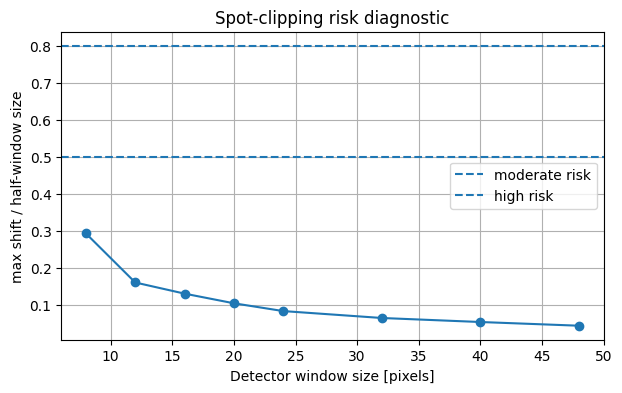

In [25]:
# ------------------------------------------------------------
# Spot-clipping risk diagnostic
# ------------------------------------------------------------

clipping_ratio = scan_window["max_shift"] / (scan_window["window_size"] / 2)

plt.figure(figsize=(7, 4))

plt.plot(
    scan_window["window_size"],
    clipping_ratio,
    marker="o",
)

plt.axhline(0.5, linestyle="--", label="moderate risk")
plt.axhline(0.8, linestyle="--", label="high risk")

plt.xlabel("Detector window size [pixels]")
plt.ylabel("max shift / half-window size")
plt.title("Spot-clipping risk diagnostic")
plt.grid(True)
plt.legend()
plt.show()

### Detector window-size scan

This scan tests the effect of finite detector windows on SH-WFS centroid measurements.

A detector window that is too small can clip the lenslet focal spot, especially when the local wavefront tilt is large. Spot clipping introduces centroid bias, reduces the valid centroid fraction, and degrades the reconstructed wavefront.

Increasing the detector window size reduces clipping risk, but in a real instrument it would also increase detector area, readout cost, and the amount of background collected per subaperture.

The clipping-risk diagnostic compares the largest measured centroid shift with the half-size of the detector window. If this ratio approaches unity, the spot is close to the edge of the detector window and the centroid measurement may no longer be reliable.

In [26]:
# ------------------------------------------------------------
# Calibration-amplitude scan
# ------------------------------------------------------------

def detector_calibration_amplitude_scan(
    W_true,
    eps_values,
    photons=None,
    read_noise_e=0.0,
    background_e=0.0,
    rcond=1e-3,
    seed=30,
):
    """
    Scan the finite-difference calibration amplitude used to build
    the detector-level SH-WFS response matrix.

    The scan is performed in the clean detector case by default,
    so that the result mainly reflects response-matrix calibration stability.
    """

    residual_rms_values = []
    cond_values = []
    rank_values = []
    valid_fraction_values = []
    min_sv_values = []
    max_sv_values = []

    for eps in eps_values:

        cfg = detector_cfg.copy()
        cfg["calibration_amplitude"] = float(eps)

        A_tmp, names_tmp, centers_tmp, masks_tmp, ref_tmp = build_detector_response_matrix(
            modes,
            mask,
            X,
            Y,
            n_lenslets=cfg["n_lenslets"],
            min_fill=cfg["min_fill"],
            pad_factor=cfg["pad_factor"],
            threshold_fraction=cfg["threshold_fraction"],
            subtract_minimum=cfg["subtract_minimum"],
            detector_window_size=cfg["detector_window_size"],
            calibration_amplitude=cfg["calibration_amplitude"],
            differential=True,
        )

        _, shifts_tmp, diag_tmp = measure_centroid_shifts(
            W_true,
            mask,
            X,
            Y,
            n_lenslets=cfg["n_lenslets"],
            min_fill=cfg["min_fill"],
            pad_factor=cfg["pad_factor"],
            photons=photons,
            read_noise_e=read_noise_e,
            background_e=background_e,
            threshold_fraction=cfg["threshold_fraction"],
            subtract_minimum=cfg["subtract_minimum"],
            detector_window_size=cfg["detector_window_size"],
            seed=seed,
            reference=ref_tmp,
            masks=masks_tmp,
            centers=centers_tmp,
            return_diagnostics=True,
        )

        coeffs_tmp, residuals_tmp, rank_tmp, singular_values_tmp = reconstruct_from_centroid_shifts(
            shifts_tmp,
            A_tmp,
            rcond=rcond,
        )

        W_rec_tmp = synthesize_from_coefficients(
            coeffs_tmp,
            modes,
            names_tmp,
            mask,
            remove_mean=True,
        )

        res_tmp = residual_wavefront(W_true, W_rec_tmp, mask)

        residual_rms_values.append(rms(res_tmp, mask))
        rank_values.append(rank_tmp)
        valid_fraction_values.append(diag_tmp["n_valid"] / diag_tmp["n_total"])
        max_sv_values.append(singular_values_tmp[0])
        min_sv_values.append(singular_values_tmp[-1])
        cond_values.append(singular_values_tmp[0] / singular_values_tmp[-1])

    return {
        "eps": np.array(eps_values),
        "residual_rms": np.array(residual_rms_values),
        "condition_number": np.array(cond_values),
        "rank": np.array(rank_values),
        "valid_fraction": np.array(valid_fraction_values),
        "max_singular_value": np.array(max_sv_values),
        "min_singular_value": np.array(min_sv_values),
    }

In [27]:
# ------------------------------------------------------------
# Run calibration-amplitude scan
# ------------------------------------------------------------

if "W_fixed" in globals():
    W_calib = W_fixed
    calib_test_name = "fixed low-order Zernike wavefront"
else:
    W_calib = W_test
    calib_test_name = "test wavefront"

eps_values = np.logspace(-5, -1, 7)

scan_calib = detector_calibration_amplitude_scan(
    W_calib,
    eps_values=eps_values,
    photons=None,
    read_noise_e=0.0,
    background_e=0.0,
    rcond=1e-3,
    seed=30,
)

print(f"Calibration-amplitude scan using: {calib_test_name}")
print("------------------------------------------------")
for i, eps in enumerate(scan_calib["eps"]):
    print(
        f"eps={eps:.1e} rad | "
        f"residual RMS={scan_calib['residual_rms'][i]:.4e} rad | "
        f"cond={scan_calib['condition_number'][i]:.3e} | "
        f"rank={scan_calib['rank'][i]:2d} | "
        f"valid frac={scan_calib['valid_fraction'][i]:.3f}"
    )

Calibration-amplitude scan using: fixed low-order Zernike wavefront
------------------------------------------------
eps=1.0e-05 rad | residual RMS=4.5228e-02 rad | cond=5.710e+00 | rank=10 | valid frac=1.000
eps=4.6e-05 rad | residual RMS=4.5229e-02 rad | cond=5.710e+00 | rank=10 | valid frac=1.000
eps=2.2e-04 rad | residual RMS=4.5229e-02 rad | cond=5.710e+00 | rank=10 | valid frac=1.000
eps=1.0e-03 rad | residual RMS=4.5229e-02 rad | cond=5.710e+00 | rank=10 | valid frac=1.000
eps=4.6e-03 rad | residual RMS=4.5229e-02 rad | cond=5.710e+00 | rank=10 | valid frac=1.000
eps=2.2e-02 rad | residual RMS=5.0845e-02 rad | cond=6.111e+00 | rank=10 | valid frac=1.000
eps=1.0e-01 rad | residual RMS=3.0660e-02 rad | cond=6.486e+00 | rank=10 | valid frac=1.000


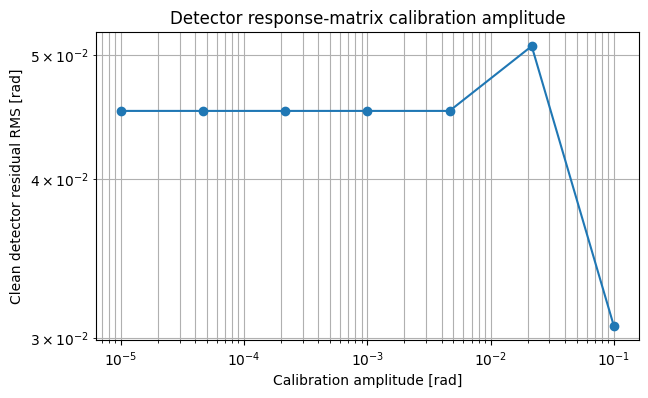

In [28]:
# ------------------------------------------------------------
# Plot residual RMS vs calibration amplitude
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.loglog(
    scan_calib["eps"],
    scan_calib["residual_rms"],
    marker="o",
)

plt.xlabel("Calibration amplitude [rad]")
plt.ylabel("Clean detector residual RMS [rad]")
plt.title("Detector response-matrix calibration amplitude")
plt.grid(True, which="both")
plt.show()

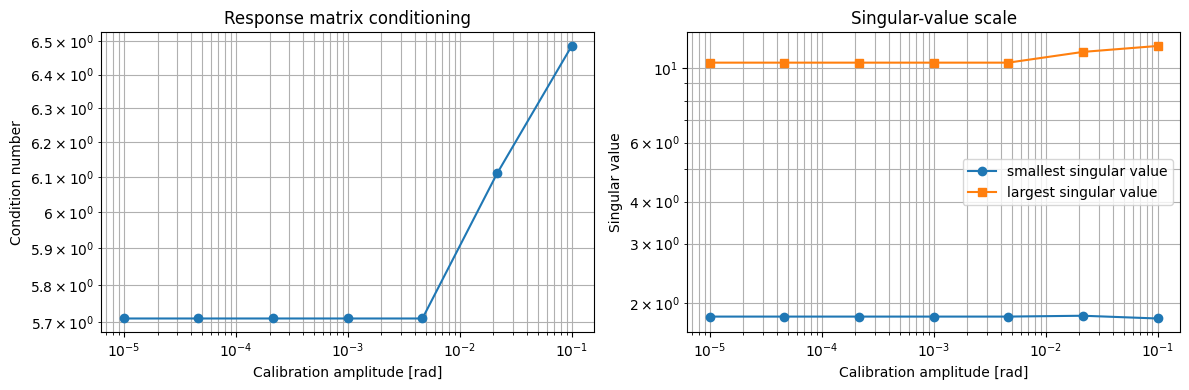

In [29]:
# ------------------------------------------------------------
# Plot conditioning vs calibration amplitude
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(
    scan_calib["eps"],
    scan_calib["condition_number"],
    marker="o",
)
axes[0].set_xlabel("Calibration amplitude [rad]")
axes[0].set_ylabel("Condition number")
axes[0].set_title("Response matrix conditioning")
axes[0].grid(True, which="both")

axes[1].loglog(
    scan_calib["eps"],
    scan_calib["min_singular_value"],
    marker="o",
    label="smallest singular value",
)
axes[1].loglog(
    scan_calib["eps"],
    scan_calib["max_singular_value"],
    marker="s",
    label="largest singular value",
)
axes[1].set_xlabel("Calibration amplitude [rad]")
axes[1].set_ylabel("Singular value")
axes[1].set_title("Singular-value scale")
axes[1].grid(True, which="both")
axes[1].legend()

plt.tight_layout()
plt.show()

In [30]:
# ------------------------------------------------------------
# Suggest a stable calibration amplitude
# ------------------------------------------------------------

eps = scan_calib["eps"]
res = scan_calib["residual_rms"]
cond = scan_calib["condition_number"]
rank = scan_calib["rank"]

# Prefer a genuinely small finite-difference amplitude.
# Do not choose a large-amplitude point just because it gives
# a slightly smaller residual for this particular test wavefront.
preferred_eps = 1e-3

idx_ref = np.argmin(np.abs(eps - preferred_eps))
ref_res = res[idx_ref]
ref_cond = cond[idx_ref]
max_rank = np.nanmax(rank)

stable = (
    np.isfinite(res)
    & np.isfinite(cond)
    & (rank == max_rank)
    & (eps >= 1e-5)
    & (eps <= 1e-2)
    & (res <= 1.2 * ref_res)
    & (cond <= 2.0 * ref_cond)
)

if np.any(stable):
    stable_eps = eps[stable]

    # Choose the stable point closest to the preferred small amplitude.
    idx_best_local = np.argmin(np.abs(np.log10(stable_eps) - np.log10(preferred_eps)))
    suggested_eps = stable_eps[idx_best_local]

    idx_suggested = np.where(eps == suggested_eps)[0][0]

    print("Suggested calibration amplitude")
    print("--------------------------------")
    print(f"suggested eps:       {suggested_eps:.2e} rad")
    print(f"residual RMS:        {res[idx_suggested]:.4e} rad")
    print(f"condition number:    {cond[idx_suggested]:.3e}")
    print()
    print("Interpretation:")
    print("The recommendation is chosen from the small-amplitude stable plateau,")
    print("not from the global minimum over all amplitudes.")
else:
    print("No stable small-amplitude plateau found.")
    print("Keep the default eps = 1e-3 rad unless the scan clearly shows instability.")

Suggested calibration amplitude
--------------------------------
suggested eps:       1.00e-03 rad
residual RMS:        4.5229e-02 rad
condition number:    5.710e+00

Interpretation:
The recommendation is chosen from the small-amplitude stable plateau,
not from the global minimum over all amplitudes.


The scan shows that the response matrix is stable over a broad small-amplitude range. Although the largest tested amplitude can sometimes give a lower residual for this specific wavefront, it is not a proper local linear calibration amplitude. Therefore, the default calibration amplitude `1e-3 rad` is retained.

### Calibration-amplitude scan

The detector-level response matrix is calibrated by applying a small positive and negative amplitude to each reconstructed mode and measuring the resulting centroid shifts.

The calibration amplitude must be chosen carefully.

- If the amplitude is too small, the induced centroid displacement becomes comparable to numerical precision, detector sampling effects, or centroiding bias.
- If the amplitude is too large, the spot displacement may leave the linear response regime, and the finite-difference derivative no longer represents the local response.
- A stable plateau in residual RMS and matrix conditioning indicates a suitable calibration regime.

In this notebook, the default value `calibration_amplitude = 1e-3 rad` is used if it lies inside the stable regime of the scan.

Noise Sensitivity Test

In [31]:
#Check how WFS slope measurement noise degrades reconstruction results.
def noise_sensitivity_curve(
    W_true,
    X,
    Y,
    mask,
    modes,
    n_lenslets=12,
    noise_values=None,
    n_trials=10,
):
    """
    Scan measurement noise and compute residual RMS.
    """
    if noise_values is None:
        noise_values = np.array([0.0, 0.002, 0.005, 0.01, 0.02, 0.05])

    mean_residuals = []
    std_residuals = []

    for noise_std in noise_values:
        trial_values = []

        for k in range(n_trials):
            result = run_wfs_reconstruction(
                W_true,
                X,
                Y,
                mask,
                modes,
                n_lenslets=n_lenslets,
                noise_std=noise_std,
                seed=100 + k,
            )

            trial_values.append(result["residual_rms"])

        mean_residuals.append(np.mean(trial_values))
        std_residuals.append(np.std(trial_values))

    return np.array(noise_values), np.array(mean_residuals), np.array(std_residuals)

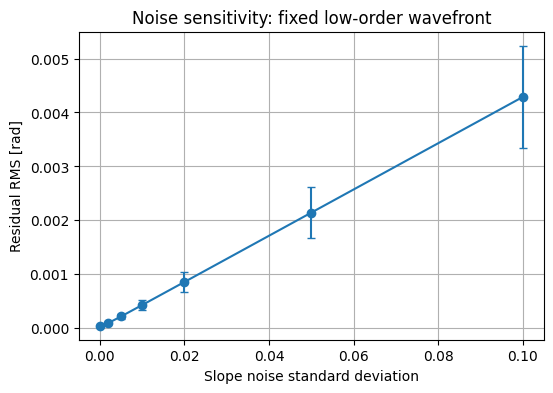

In [32]:
noise_values = np.array([0.0, 0.002, 0.005, 0.01, 0.02, 0.05, 0.10])

noise_fixed, mean_fixed, std_fixed = noise_sensitivity_curve(
    W_fixed,
    X,
    Y,
    mask,
    modes,
    n_lenslets=12,
    noise_values=noise_values,
    n_trials=20,
)

plt.figure(figsize=(6, 4))
plt.errorbar(
    noise_fixed,
    mean_fixed,
    yerr=std_fixed,
    marker="o",
    capsize=3,
)
plt.xlabel("Slope noise standard deviation")
plt.ylabel("Residual RMS [rad]")
plt.title("Noise sensitivity: fixed low-order wavefront")
plt.grid(True)
plt.show()

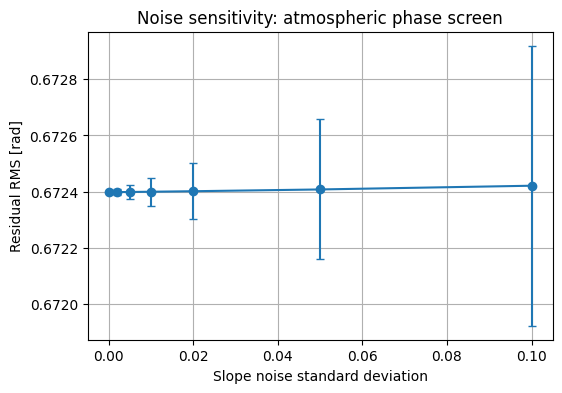

In [33]:
noise_atm, mean_atm, std_atm = noise_sensitivity_curve(
    W_atm,
    X,
    Y,
    mask,
    modes,
    n_lenslets=14,
    noise_values=noise_values,
    n_trials=20,
)

plt.figure(figsize=(6, 4))
plt.errorbar(
    noise_atm,
    mean_atm,
    yerr=std_atm,
    marker="o",
    capsize=3,
)
plt.xlabel("Slope noise standard deviation")
plt.ylabel("Residual RMS [rad]")
plt.title("Noise sensitivity: atmospheric phase screen")
plt.grid(True)
plt.show()

In [34]:
def photon_sensitivity_curve_detector(
    W_true,
    X,
    Y,
    mask,
    modes,
    n_lenslets=14,
    photon_values=None,
    n_trials=10,
    read_noise_e=1.0,
    background_e=2.0,
    pad_factor=4,
    threshold_fraction=0.02,
    subtract_minimum=True,
    detector_window_size=24,
):
    """
    Scan detector photon count and compute reconstruction residual RMS.
    """
    if photon_values is None:
        photon_values = np.array([300, 1000, 3000, 10000, 30000, 100000])

    mean_residuals = []
    std_residuals = []
    valid_fractions = []

    for photons in photon_values:
        trial_values = []
        valid_values = []

        for k in range(n_trials):
            result = run_wfs_reconstruction_detector(
                W_true,
                X,
                Y,
                mask,
                modes,
                n_lenslets=n_lenslets,
                photons=photons,
                read_noise_e=read_noise_e,
                background_e=background_e,
                pad_factor=pad_factor,
                threshold_fraction=threshold_fraction,
                subtract_minimum=subtract_minimum,
                detector_window_size=detector_window_size,
                seed=100 + k,
            )

            trial_values.append(result["residual_rms"])
            valid_values.append(
                result["n_valid_centroids"] / result["n_total_centroids"]
            )

        mean_residuals.append(np.mean(trial_values))
        std_residuals.append(np.std(trial_values))
        valid_fractions.append(np.mean(valid_values))

    return (
        np.asarray(photon_values),
        np.asarray(mean_residuals),
        np.asarray(std_residuals),
        np.asarray(valid_fractions),
    )

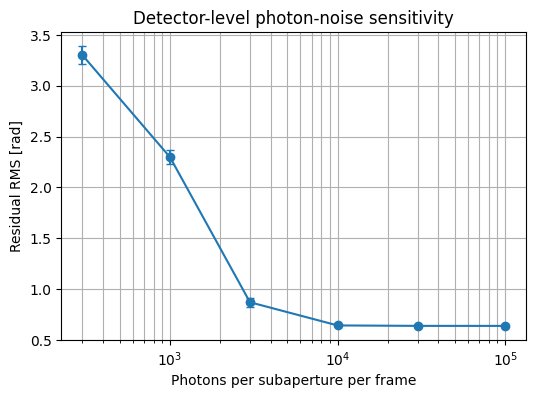

In [35]:
photon_values = np.array([300, 1000, 3000, 10000, 30000, 100000])

photons, mean_det, std_det, valid_frac = photon_sensitivity_curve_detector(
    W_atm,
    X,
    Y,
    mask,
    modes,
    n_lenslets=14,
    photon_values=photon_values,
    n_trials=10,
    read_noise_e=1.0,
    background_e=2.0,
    pad_factor=4,
    threshold_fraction=0.02,
    subtract_minimum=True,
    detector_window_size=24,
)

plt.figure(figsize=(6, 4))
plt.errorbar(
    photons,
    mean_det,
    yerr=std_det,
    marker="o",
    capsize=3,
)
plt.xscale("log")
plt.xlabel("Photons per subaperture per frame")
plt.ylabel("Residual RMS [rad]")
plt.title("Detector-level photon-noise sensitivity")
plt.grid(True, which="both")
plt.show()

The impact of sub-aperture quantity on the quality of reconstruction

In [36]:
def lenslet_number_scan(
    W_true,
    X,
    Y,
    mask,
    modes,
    lenslet_values=None,
    noise_std=0.0,
):
    """
    Scan number of lenslets across the pupil and compute residual RMS.
    """
    if lenslet_values is None:
        lenslet_values = np.array([6, 8, 10, 12, 14, 16, 20, 24])

    residual_values = []
    rank_values = []
    n_subap_values = []

    for n_lenslets in lenslet_values:
        result = run_wfs_reconstruction(
            W_true,
            X,
            Y,
            mask,
            modes,
            n_lenslets=int(n_lenslets),
            noise_std=noise_std,
            seed=1,
        )

        residual_values.append(result["residual_rms"])
        rank_values.append(result["rank"])
        n_subap_values.append(len(result["centers"]))

    return (
        np.array(lenslet_values),
        np.array(residual_values),
        np.array(rank_values),
        np.array(n_subap_values),
    )

def lenslet_number_scan_detector(
    W_true,
    X,
    Y,
    mask,
    modes,
    lenslet_values=None,
    total_photons_per_frame=3e5,
    read_noise_e=1.0,
    background_e=2.0,
    pad_factor=4,
    threshold_fraction=0.02,
    subtract_minimum=True,
    detector_window_size=24,
):
    if lenslet_values is None:
        lenslet_values = np.array([6, 8, 10, 12, 14, 16, 20])

    residual_values = []
    rank_values = []
    n_subap_values = []
    photons_per_subap_values = []

    for n_lenslets in lenslet_values:
        # First build response matrix to know the number of valid subapertures.
        A_det, names, centers, masks_det, reference = build_detector_response_matrix(
            modes,
            mask,
            X,
            Y,
            n_lenslets=int(n_lenslets),
            min_fill=0.5,
            pad_factor=pad_factor,
            threshold_fraction=threshold_fraction,
            subtract_minimum=subtract_minimum,
            detector_window_size=detector_window_size,
            calibration_amplitude=1e-3,
            differential=True,
        )

        photons_per_subap = total_photons_per_frame / len(centers)

        _, shifts, diag = measure_centroid_shifts(
            W_true,
            mask,
            X,
            Y,
            n_lenslets=int(n_lenslets),
            min_fill=0.5,
            pad_factor=pad_factor,
            photons=photons_per_subap,
            read_noise_e=read_noise_e,
            background_e=background_e,
            threshold_fraction=threshold_fraction,
            subtract_minimum=subtract_minimum,
            detector_window_size=detector_window_size,
            reference=reference,
            masks=masks_det,
            centers=centers,
            return_diagnostics=True,
        )

        coeffs, residuals, rank, singular_values = reconstruct_from_centroid_shifts(
            shifts,
            A_det,
            rcond=1e-3,
        )

        W_rec = synthesize_from_coefficients(
            coeffs,
            modes,
            names,
            mask,
            remove_mean=True,
        )

        res = residual_wavefront(W_true, W_rec, mask)

        residual_values.append(rms(res, mask))
        rank_values.append(rank)
        n_subap_values.append(len(centers))
        photons_per_subap_values.append(photons_per_subap)

    return (
        np.asarray(lenslet_values),
        np.asarray(residual_values),
        np.asarray(rank_values),
        np.asarray(n_subap_values),
        np.asarray(photons_per_subap_values),
    )

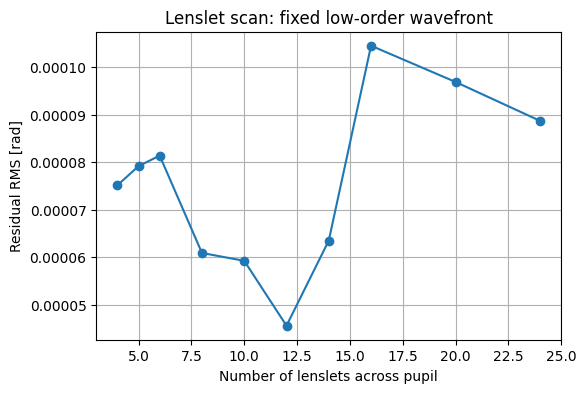

n_lenslets =  4, valid subapertures =  12, rank = 10, residual RMS = 7.5170e-05
n_lenslets =  5, valid subapertures =  21, rank = 10, residual RMS = 7.9200e-05
n_lenslets =  6, valid subapertures =  32, rank = 10, residual RMS = 8.1408e-05
n_lenslets =  8, valid subapertures =  52, rank = 10, residual RMS = 6.0919e-05
n_lenslets = 10, valid subapertures =  80, rank = 10, residual RMS = 5.9271e-05
n_lenslets = 12, valid subapertures = 112, rank = 10, residual RMS = 4.5609e-05
n_lenslets = 14, valid subapertures = 156, rank = 10, residual RMS = 6.3538e-05
n_lenslets = 16, valid subapertures = 208, rank = 10, residual RMS = 1.0454e-04
n_lenslets = 20, valid subapertures = 316, rank = 10, residual RMS = 9.6912e-05
n_lenslets = 24, valid subapertures = 450, rank = 10, residual RMS = 8.8721e-05


In [37]:
lenslet_values = np.array([4, 5, 6, 8, 10, 12, 14, 16, 20, 24])

lens_fixed, res_fixed, rank_fixed, nsub_fixed = lenslet_number_scan(
    W_fixed,
    X,
    Y,
    mask,
    modes,
    lenslet_values=lenslet_values,
    noise_std=0.0,
)

plt.figure(figsize=(6, 4))
plt.plot(
    lens_fixed,
    res_fixed,
    marker="o",
)
plt.xlabel("Number of lenslets across pupil")
plt.ylabel("Residual RMS [rad]")
plt.title("Lenslet scan: fixed low-order wavefront")
plt.grid(True)
plt.show()

for n, nsub, rank, res in zip(lens_fixed, nsub_fixed, rank_fixed, res_fixed):
    print(
        f"n_lenslets = {n:2d}, "
        f"valid subapertures = {nsub:3d}, "
        f"rank = {rank:2d}, "
        f"residual RMS = {res:.4e}"
    )

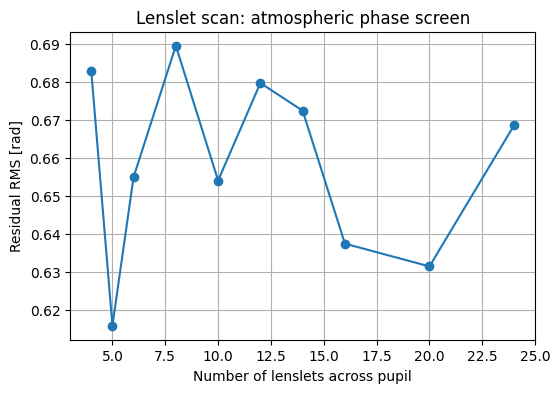

n_lenslets =  4, valid subapertures =  12, rank = 10, residual RMS = 6.8274e-01
n_lenslets =  5, valid subapertures =  21, rank = 10, residual RMS = 6.1580e-01
n_lenslets =  6, valid subapertures =  32, rank = 10, residual RMS = 6.5490e-01
n_lenslets =  8, valid subapertures =  52, rank = 10, residual RMS = 6.8951e-01
n_lenslets = 10, valid subapertures =  80, rank = 10, residual RMS = 6.5402e-01
n_lenslets = 12, valid subapertures = 112, rank = 10, residual RMS = 6.7968e-01
n_lenslets = 14, valid subapertures = 156, rank = 10, residual RMS = 6.7240e-01
n_lenslets = 16, valid subapertures = 208, rank = 10, residual RMS = 6.3740e-01
n_lenslets = 20, valid subapertures = 316, rank = 10, residual RMS = 6.3141e-01
n_lenslets = 24, valid subapertures = 450, rank = 10, residual RMS = 6.6853e-01


In [38]:
lens_atm, res_atm, rank_atm, nsub_atm = lenslet_number_scan(
    W_atm,
    X,
    Y,
    mask,
    modes,
    lenslet_values=lenslet_values,
    noise_std=0.0,
)

plt.figure(figsize=(6, 4))
plt.plot(
    lens_atm,
    res_atm,
    marker="o",
)
plt.xlabel("Number of lenslets across pupil")
plt.ylabel("Residual RMS [rad]")
plt.title("Lenslet scan: atmospheric phase screen")
plt.grid(True)
plt.show()

for n, nsub, rank, res in zip(lens_atm, nsub_atm, rank_atm, res_atm):
    print(
        f"n_lenslets = {n:2d}, "
        f"valid subapertures = {nsub:3d}, "
        f"rank = {rank:2d}, "
        f"residual RMS = {res:.4e}"
    )

In this experiment, increasing the number of lenslets does not necessarily lead to a monotonic decrease of the residual wavefront error. This is because the number of reconstructed modes is kept fixed. The Shack-Hartmann sensor samples the local slopes more finely as the number of sub-apertures increases, but the reconstructor still projects the measured slopes onto the same low-order Zernike-like modal basis.

For atmospheric turbulence, the wavefront contains high-spatial-frequency aberrations that cannot be represented by this limited modal basis. Therefore, increasing the WFS sampling alone does not remove the high-order residual. In some cases, finer sampling can even introduce more high-frequency slope information into the least-squares fit, which may slightly change the estimated low-order coefficients and produce non-monotonic residual RMS behavior.

A physically more complete AO simulation would increase both the WFS sampling and the number of controllable modes or DM actuators.

An increased number of lenslets enhances slope sampling;
however, the reconstruction basis remains limited to low-order Zernike modes,
consequently, high-order turbulent structures still cannot be fitted.

Low order AO Correction demo

In [39]:
result_atm = run_wfs_reconstruction(
    W_atm,
    X,
    Y,
    mask,
    modes,
    n_lenslets=14,
    noise_std=0.01,
    seed=2,
)

W_rec = result_atm["W_rec"]
W_corrected = result_atm["residual"]

print(f"Atmospheric RMS before correction: {rms(W_atm, mask):.4f} rad")
print(f"Residual RMS after correction:     {rms(W_corrected, mask):.4f} rad")
print(f"RMS reduction factor:              {rms(W_atm, mask) / rms(W_corrected, mask):.3f}")

Atmospheric RMS before correction: 0.9999 rad
Residual RMS after correction:     0.6724 rad
RMS reduction factor:              1.487


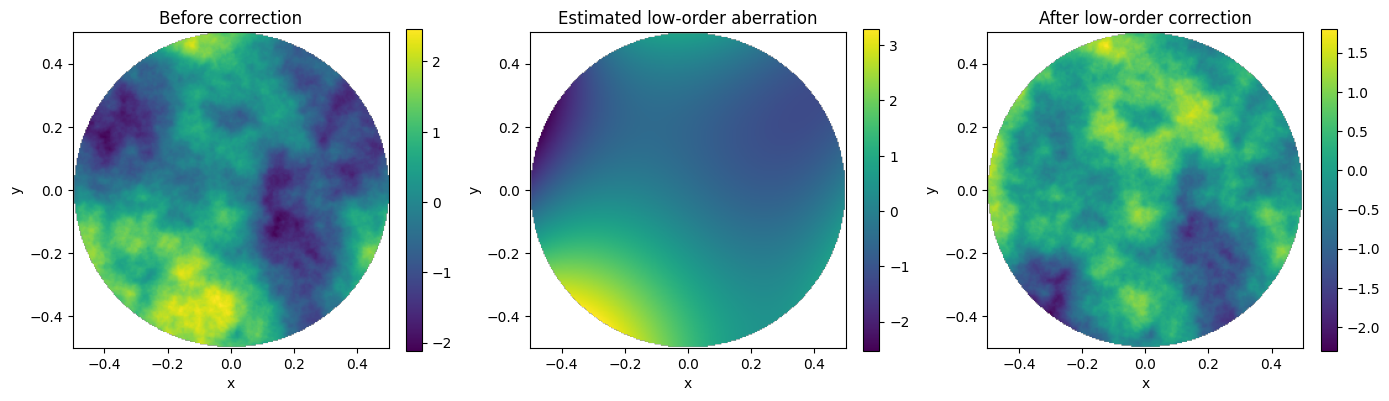

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(
    W_atm,
    extent=extent,
    origin="lower",
)
axes[0].set_title("Before correction")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(
    W_rec,
    extent=extent,
    origin="lower",
)
axes[1].set_title("Estimated low-order aberration")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(
    W_corrected,
    extent=extent,
    origin="lower",
)
axes[2].set_title("After low-order correction")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

In [41]:
# ------------------------------------------------------------
# Detector-level low-order AO correction
# ------------------------------------------------------------

if "W_atm" not in globals():
    raise RuntimeError("W_atm is not defined. Please run the atmospheric phase-screen cell first.")

# Geometric baseline, if the helper function exists
if "run_wfs_reconstruction" in globals():
    result_atm_geo = run_wfs_reconstruction(
        W_atm,
        X,
        Y,
        mask,
        modes,
        n_lenslets=detector_cfg["n_lenslets"],
        noise_std=0.01,
        seed=2,
    )
else:
    result_atm_geo = None

# Detector-level reconstruction using cached detector response matrix
result_atm_det = run_detector_cached(
    W_atm,
    photons=20000,
    read_noise_e=1.0,
    background_e=1.0,
    seed=2,
    rcond=1e-3,
)

W_rec_det = result_atm_det["W_rec"]
W_corr_det = result_atm_det["residual"]

print("Detector-level AO correction")
print("----------------------------")
print(f"Input RMS:               {result_atm_det['input_rms']:.4e} rad")
print(f"Detector residual RMS:   {result_atm_det['residual_rms']:.4e} rad")
print(f"Correction factor:       {result_atm_det['input_rms'] / result_atm_det['residual_rms']:.3f}")
print(f"Valid centroid fraction: {result_atm_det['valid_fraction']:.3f}")
print(f"Reconstruction rank:     {result_atm_det['rank']}")

if result_atm_geo is not None:
    W_rec_geo = result_atm_geo["W_rec"]
    W_corr_geo = result_atm_geo["residual"]

    print("\nGeometric baseline")
    print("------------------")
    print(f"Geometric residual RMS:  {result_atm_geo['residual_rms']:.4e} rad")
    print(f"Correction factor:       {result_atm_geo['input_rms'] / result_atm_geo['residual_rms']:.3f}")

Detector-level AO correction
----------------------------
Input RMS:               9.9992e-01 rad
Detector residual RMS:   6.4308e-01 rad
Correction factor:       1.555
Valid centroid fraction: 1.000
Reconstruction rank:     10

Geometric baseline
------------------
Geometric residual RMS:  6.7236e-01 rad
Correction factor:       1.487


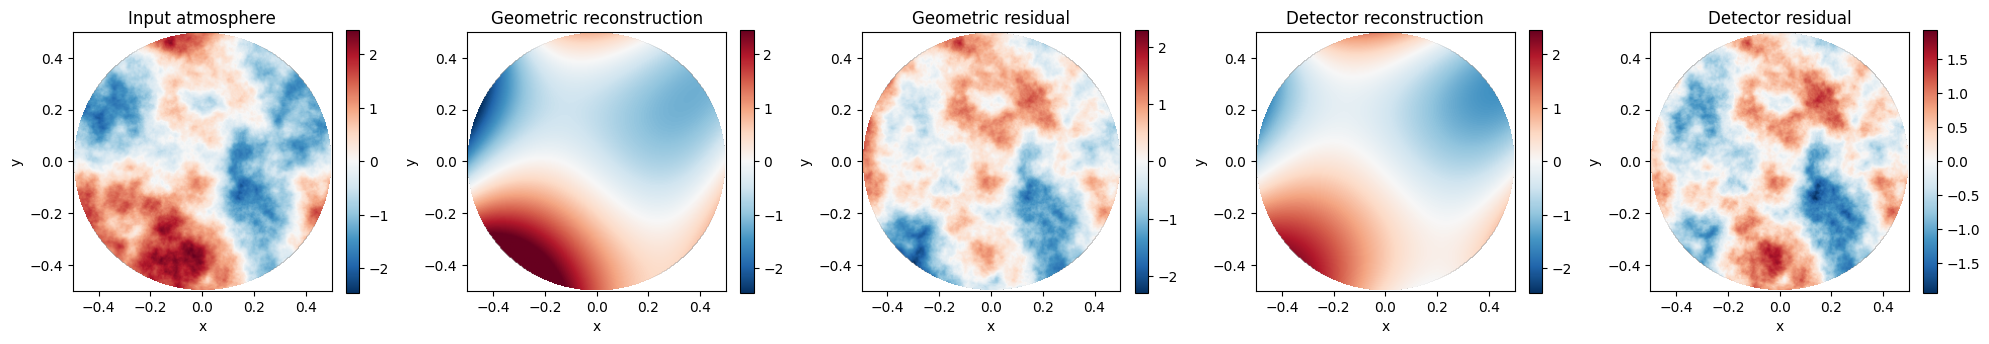

In [42]:
# ------------------------------------------------------------
# Visualize detector-level AO correction
# ------------------------------------------------------------

if result_atm_geo is not None:
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    vmax_wave = np.nanmax(np.abs(W_atm[mask]))
    vmax_geo_res = np.nanmax(np.abs(W_corr_geo[mask]))
    vmax_det_res = np.nanmax(np.abs(W_corr_det[mask]))

    items = [
        (W_atm, "Input atmosphere", vmax_wave),
        (W_rec_geo, "Geometric reconstruction", vmax_wave),
        (W_corr_geo, "Geometric residual", vmax_geo_res),
        (W_rec_det, "Detector reconstruction", vmax_wave),
        (W_corr_det, "Detector residual", vmax_det_res),
    ]

else:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    vmax_wave = np.nanmax(np.abs(W_atm[mask]))
    vmax_det_res = np.nanmax(np.abs(W_corr_det[mask]))

    items = [
        (W_atm, "Input atmosphere", vmax_wave),
        (W_rec_det, "Detector reconstruction", vmax_wave),
        (W_corr_det, "Detector residual", vmax_det_res),
    ]

for ax, (img, title, scale) in zip(np.ravel(axes), items):
    im = ax.imshow(
        np.where(mask, img, np.nan),
        extent=extent,
        origin="lower",
        cmap="RdBu_r",
        vmin=-scale,
        vmax=scale,
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

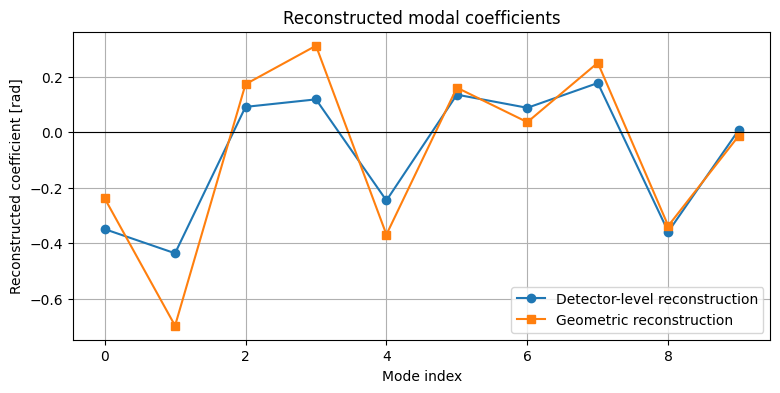

In [43]:
# ------------------------------------------------------------
# Compare reconstructed modal coefficients
# ------------------------------------------------------------

coeff_det = result_atm_det["coeffs"]

plt.figure(figsize=(9, 4))

plt.plot(
    np.arange(len(coeff_det)),
    coeff_det,
    marker="o",
    label="Detector-level reconstruction",
)

if result_atm_geo is not None and "coeffs" in result_atm_geo:
    coeff_geo = result_atm_geo["coeffs"]
    plt.plot(
        np.arange(len(coeff_geo)),
        coeff_geo,
        marker="s",
        label="Geometric reconstruction",
    )

plt.axhline(0.0, color="k", linewidth=0.8)
plt.xlabel("Mode index")
plt.ylabel("Reconstructed coefficient [rad]")
plt.title("Reconstructed modal coefficients")
plt.grid(True)
plt.legend()
plt.show()

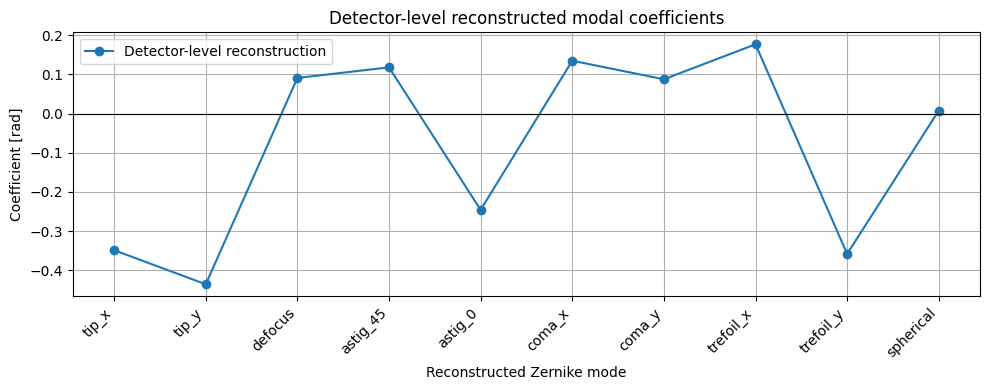

In [44]:
plt.figure(figsize=(10, 4))

plt.plot(
    np.arange(len(coeff_det)),
    coeff_det,
    marker="o",
    label="Detector-level reconstruction",
)

plt.xticks(
    np.arange(len(names_det)),
    names_det,
    rotation=45,
    ha="right",
)

plt.axhline(0.0, color="k", linewidth=0.8)
plt.xlabel("Reconstructed Zernike mode")
plt.ylabel("Coefficient [rad]")
plt.title("Detector-level reconstructed modal coefficients")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
# ------------------------------------------------------------
# Residual statistics
# ------------------------------------------------------------

def print_wavefront_stats(label, W):
    values = W[mask]
    print(f"{label}")
    print("-" * len(label))
    print(f"RMS:     {rms(W, mask):.4e} rad")
    print(f"Mean:    {np.nanmean(values):.4e} rad")
    print(f"Std:     {np.nanstd(values):.4e} rad")
    print(f"Min:     {np.nanmin(values):.4e} rad")
    print(f"Max:     {np.nanmax(values):.4e} rad")
    print()

print_wavefront_stats("Input atmosphere", W_atm)

if result_atm_geo is not None:
    print_wavefront_stats("Geometric residual", W_corr_geo)

print_wavefront_stats("Detector-level residual", W_corr_det)

Input atmosphere
----------------
RMS:     9.9992e-01 rad
Mean:    3.4963e-04 rad
Std:     9.9992e-01 rad
Min:     -2.1130e+00 rad
Max:     2.4584e+00 rad

Geometric residual
------------------
RMS:     6.7236e-01 rad
Mean:    -1.7872e-17 rad
Std:     6.7236e-01 rad
Min:     -2.3018e+00 rad
Max:     1.7992e+00 rad

Detector-level residual
-----------------------
RMS:     6.4308e-01 rad
Mean:    -8.9359e-18 rad
Std:     6.4308e-01 rad
Min:     -1.9403e+00 rad
Max:     1.6873e+00 rad



### Detector-level low-order AO correction

This section applies the detector-level SH-WFS pipeline to a turbulent atmospheric phase screen.

Unlike the ideal geometric model, the detector-level reconstruction does not measure local wavefront slopes directly. Instead, it forms lenslet focal spots, adds detector noise, estimates centroid shifts, and reconstructs the low-order modal wavefront from those noisy centroid measurements.

The detector-level residual therefore includes several additional error sources:

- finite detector sampling,
- finite detector window size,
- photon noise,
- read noise,
- background noise,
- centroid bias,
- response-matrix conditioning,
- and modal truncation.

The geometric reconstruction should be interpreted as an idealized upper-performance baseline, while the detector-level reconstruction is closer to a physically realistic SH-WFS measurement chain.

Comparison of different turbulence

In [46]:
# ------------------------------------------------------------
# Turbulence seed comparison:
# geometric baseline vs detector-level reconstruction
# ------------------------------------------------------------

seeds = [1, 2, 3, 4, 5, 10, 20, 30]

before_values = []
after_geo_values = []
after_det_values = []

for seed in seeds:
    W_tmp = make_random_atmospheric_wavefront(
        N=N,
        dx=dx,
        diameter=diameter,
        r0=0.20,
        L0=25.0,
        seed=seed,
        target_rms_rad=1.0,
    )

    # Idealized geometric SH-WFS baseline
    result_geo_tmp = run_wfs_reconstruction(
        W_tmp,
        X,
        Y,
        mask,
        modes,
        n_lenslets=detector_cfg["n_lenslets"],
        noise_std=0.01,
        seed=100 + seed,
    )

    # Detector-level SH-WFS reconstruction
    result_det_tmp = run_detector_cached(
        W_tmp,
        photons=20000,
        read_noise_e=1.0,
        background_e=1.0,
        seed=200 + seed,
        rcond=1e-3,
    )

    before_values.append(rms(W_tmp, mask))
    after_geo_values.append(result_geo_tmp["residual_rms"])
    after_det_values.append(result_det_tmp["residual_rms"])

before_values = np.array(before_values)
after_geo_values = np.array(after_geo_values)
after_det_values = np.array(after_det_values)

print("Turbulence seed comparison")
print("--------------------------")
print(f"Mean RMS before correction:       {np.mean(before_values):.4f} rad")
print(f"Mean RMS after geometric AO:      {np.mean(after_geo_values):.4f} rad")
print(f"Mean RMS after detector AO:       {np.mean(after_det_values):.4f} rad")
print()
print(f"Mean geometric reduction factor:  {np.mean(before_values / after_geo_values):.3f}")
print(f"Mean detector reduction factor:   {np.mean(before_values / after_det_values):.3f}")

Turbulence seed comparison
--------------------------
Mean RMS before correction:       1.0000 rad
Mean RMS after geometric AO:      1.0000 rad
Mean RMS after detector AO:       0.9999 rad

Mean geometric reduction factor:  1.000
Mean detector reduction factor:   1.000


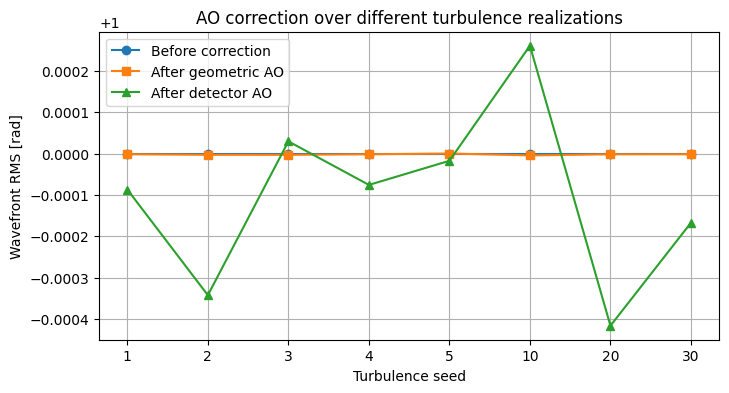

In [47]:
# ------------------------------------------------------------
# Plot turbulence seed comparison
# ------------------------------------------------------------

x = np.arange(len(seeds))

plt.figure(figsize=(8, 4))

plt.plot(
    x,
    before_values,
    marker="o",
    label="Before correction",
)

plt.plot(
    x,
    after_geo_values,
    marker="s",
    label="After geometric AO",
)

plt.plot(
    x,
    after_det_values,
    marker="^",
    label="After detector AO",
)

plt.xticks(x, seeds)
plt.xlabel("Turbulence seed")
plt.ylabel("Wavefront RMS [rad]")
plt.title("AO correction over different turbulence realizations")
plt.grid(True)
plt.legend()
plt.show()

PSF and Strehl-ratio

In [48]:
def compute_psf_from_phase(phase_rad, mask, pad_factor=4):
    """
    Compute focal-plane PSF from pupil phase.

    Parameters
    ----------
    phase_rad : ndarray
        Phase aberration in radians.
    mask : ndarray
        Pupil mask.
    pad_factor : int
        Zero-padding factor for better PSF sampling.

    Returns
    -------
    psf : ndarray
        Normalized PSF.
    """
    N = phase_rad.shape[0]

    pupil_field = np.zeros_like(phase_rad, dtype=complex)
    phase_clean = np.nan_to_num(phase_rad, nan=0.0)

    pupil_field[mask] = np.exp(1j * phase_clean[mask])

    pad_N = pad_factor * N
    padded = np.zeros((pad_N, pad_N), dtype=complex)

    start = (pad_N - N) // 2
    end = start + N
    padded[start:end, start:end] = pupil_field

    focal_field = np.fft.fftshift(
        np.fft.fft2(
            np.fft.ifftshift(padded)
        )
    )

    psf = np.abs(focal_field) ** 2
    psf /= np.sum(psf)

    return psf


def strehl_ratio(phase_rad, mask, pad_factor=4):
    """
    Compute approximate Strehl ratio.

    Strehl = peak aberrated PSF / peak diffraction-limited PSF
    """
    psf_aberrated = compute_psf_from_phase(
        phase_rad,
        mask,
        pad_factor=pad_factor,
    )

    ideal_phase = np.zeros_like(phase_rad)

    psf_ideal = compute_psf_from_phase(
        ideal_phase,
        mask,
        pad_factor=pad_factor,
    )

    return np.max(psf_aberrated) / np.max(psf_ideal)

In [49]:
# ------------------------------------------------------------
# PSF and Strehl: detector-level AO correction
# ------------------------------------------------------------

pad_factor_psf = 4

psf_ideal = compute_psf_from_phase(
    np.zeros_like(W_atm),
    mask,
    pad_factor=pad_factor_psf,
)

psf_before = compute_psf_from_phase(
    W_atm,
    mask,
    pad_factor=pad_factor_psf,
)

psf_after_det = compute_psf_from_phase(
    W_corr_det,
    mask,
    pad_factor=pad_factor_psf,
)

ideal_peak = np.max(psf_ideal)

strehl_before = np.max(psf_before) / ideal_peak
strehl_after_det = np.max(psf_after_det) / ideal_peak

print(f"Strehl before correction:          {strehl_before:.4f}")
print(f"Strehl after detector-level AO:    {strehl_after_det:.4f}")
print(f"Improvement factor:                {strehl_after_det / strehl_before:.3f}")

Strehl before correction:          0.4567
Strehl after detector-level AO:    0.6570
Improvement factor:                1.438


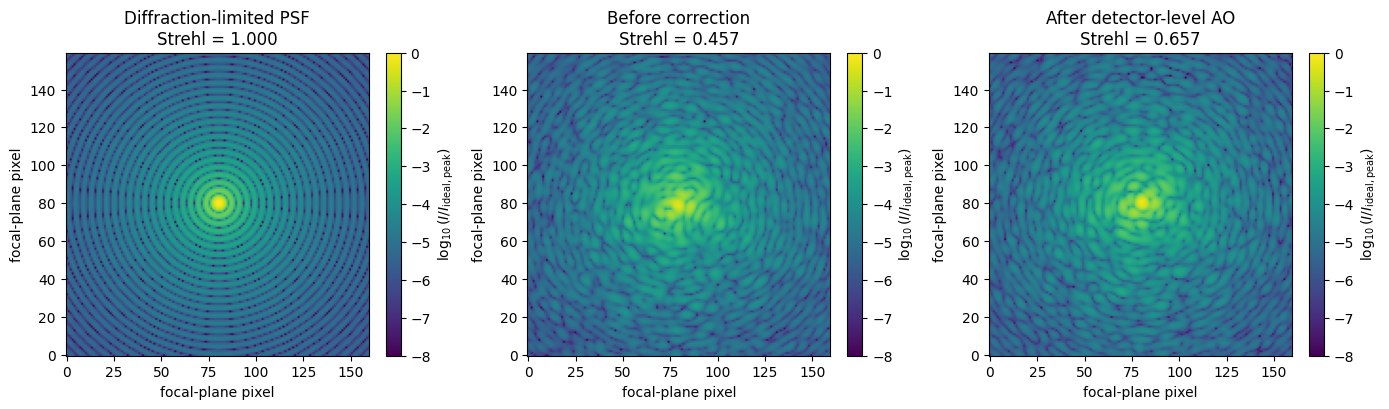

In [50]:
# ------------------------------------------------------------
# 2D log-scale PSF comparison
# normalized by diffraction-limited PSF peak
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

crop = 80
center = psf_before.shape[0] // 2
sl = slice(center - crop, center + crop)

psf_items = [
    (
        psf_ideal,
        "Diffraction-limited PSF\nStrehl = 1.000",
    ),
    (
        psf_before,
        f"Before correction\nStrehl = {strehl_before:.3f}",
    ),
    (
        psf_after_det,
        f"After detector-level AO\nStrehl = {strehl_after_det:.3f}",
    ),
]

for ax, (psf, title) in zip(axes, psf_items):
    psf_norm = psf / ideal_peak
    psf_log = np.log10(np.maximum(psf_norm, 1e-8))

    im = ax.imshow(
        psf_log[sl, sl],
        origin="lower",
        vmin=-8,
        vmax=0,
    )

    ax.set_title(title)
    ax.set_xlabel("focal-plane pixel")
    ax.set_ylabel("focal-plane pixel")
    plt.colorbar(im, ax=ax, fraction=0.046, label=r"$\log_{10}(I/I_{\rm ideal,peak})$")

plt.tight_layout()
plt.show()

In [51]:
from mpl_toolkits.mplot3d import Axes3D


def plot_psf_surface_3d(
    psf,
    title="PSF",
    crop=80,
    stride=2,
    log_scale=True,
):
    """
    Plot PSF as a 3D surface.

    Parameters
    ----------
    psf : ndarray
        Normalized PSF.
    title : str
        Plot title.
    crop : int
        Half-size of central crop.
    stride : int
        Downsampling stride for plotting.
    log_scale : bool
        If True, plot log10 normalized intensity.
        If False, plot linear normalized intensity.
    """
    center = psf.shape[0] // 2
    sl = slice(center - crop, center + crop)

    psf_crop = psf[sl, sl]
    psf_crop = psf_crop / np.max(psf_crop)

    if log_scale:
        Z = np.log10(psf_crop + 1e-8)
        zlabel = "log10 normalized intensity"
    else:
        Z = psf_crop
        zlabel = "normalized intensity"

    Z = Z[::stride, ::stride]

    ny, nx = Z.shape
    x = np.arange(nx)
    y = np.arange(ny)
    Xp, Yp = np.meshgrid(x, y)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(
        Xp,
        Yp,
        Z,
        linewidth=0,
        antialiased=True,
    )

    ax.set_title(title)
    ax.set_xlabel("focal-plane x [pixel]")
    ax.set_ylabel("focal-plane y [pixel]")
    ax.set_zlabel(zlabel)

    plt.tight_layout()
    plt.show()

In [52]:
def plot_three_psf_surfaces_3d_same_scale(
    psf_ideal,
    psf_before,
    psf_after,
    crop=70,
    stride=2,
    log_scale=True,
    after_label="After detector-level AO",
):
    """
    Plot ideal, before-correction, and after-correction PSFs
    using the same absolute normalization.

    All PSFs are normalized by the peak of the diffraction-limited PSF.
    This makes the Strehl-ratio difference visually meaningful.
    """
    reference_peak = np.max(psf_ideal)

    strehl_before_local = np.max(psf_before) / reference_peak
    strehl_after_local = np.max(psf_after) / reference_peak

    psfs = [
        psf_ideal / reference_peak,
        psf_before / reference_peak,
        psf_after / reference_peak,
    ]

    titles = [
        "Diffraction-limited PSF\nStrehl = 1.000",
        f"Before correction\nStrehl = {strehl_before_local:.3f}",
        f"{after_label}\nStrehl = {strehl_after_local:.3f}",
    ]

    fig = plt.figure(figsize=(18, 5))

    for i, (psf_norm, title) in enumerate(zip(psfs, titles), start=1):
        center = psf_norm.shape[0] // 2
        sl = slice(center - crop, center + crop)

        psf_crop = psf_norm[sl, sl]

        if log_scale:
            Z = np.log10(np.maximum(psf_crop, 1e-8))
            zlabel = r"$\log_{10}(I/I_{\rm ideal,peak})$"
            zlim = (-8, 0)
        else:
            Z = psf_crop
            zlabel = r"$I/I_{\rm ideal,peak}$"
            zlim = (0, 1)

        Z = Z[::stride, ::stride]

        ny, nx = Z.shape
        x = np.arange(nx)
        y = np.arange(ny)
        Xp, Yp = np.meshgrid(x, y)

        ax = fig.add_subplot(1, 3, i, projection="3d")

        ax.plot_surface(
            Xp,
            Yp,
            Z,
            linewidth=0,
            antialiased=True,
        )

        ax.set_title(title)
        ax.set_xlabel("x [pixel]")
        ax.set_ylabel("y [pixel]")
        ax.set_zlabel(zlabel)
        ax.set_zlim(*zlim)

    plt.tight_layout()
    plt.show()

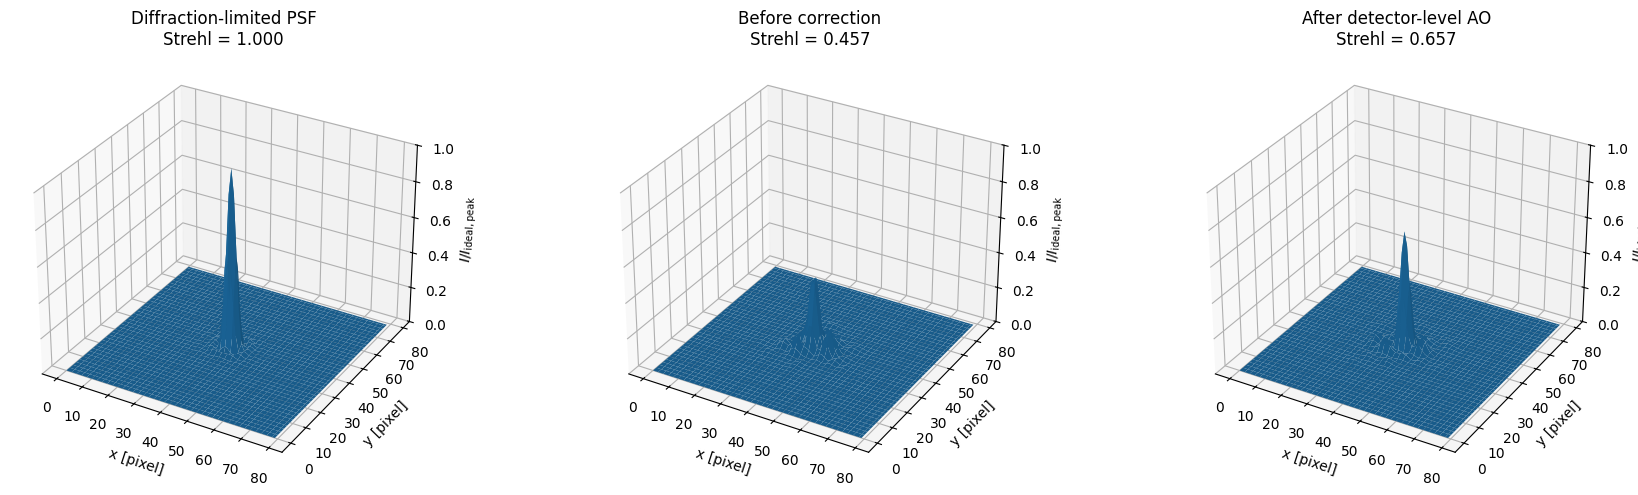

In [53]:
plot_three_psf_surfaces_3d_same_scale(
    psf_ideal,
    psf_before,
    psf_after_det,
    crop=40,
    stride=1,
    log_scale=False,
    after_label="After detector-level AO",
)

In [54]:
def radial_profile(psf, center=None):
    """
    Compute azimuthally averaged radial profile of a PSF.
    """
    ny, nx = psf.shape

    if center is None:
        center = (nx // 2, ny // 2)

    x = np.arange(nx)
    y = np.arange(ny)
    Xp, Yp = np.meshgrid(x, y)

    r = np.sqrt((Xp - center[0])**2 + (Yp - center[1])**2)
    r_int = r.astype(int)

    profile = np.bincount(
        r_int.ravel(),
        weights=psf.ravel(),
    ) / np.bincount(r_int.ravel())

    radius = np.arange(len(profile))

    return radius, profile

In [55]:
# ------------------------------------------------------------
# PSF and Strehl diagnostics
# ------------------------------------------------------------

required_psf_functions = ["compute_psf_from_phase", "strehl_ratio"]

for fn in required_psf_functions:
    if fn not in globals():
        raise RuntimeError(
            f"{fn} is not defined. Please check whether psf_tools.py was imported correctly."
        )

if "W_corr_det" not in globals():
    raise RuntimeError("W_corr_det is not defined. Please run Step 8 first.")

print("PSF tools are available.")

PSF tools are available.


In [56]:
# ------------------------------------------------------------
# Compute PSFs and Strehl ratios
# ------------------------------------------------------------

pad_factor_psf = 4

psf_ideal = compute_psf_from_phase(
    np.zeros_like(W_atm),
    mask,
    pad_factor=pad_factor_psf,
)

psf_before = compute_psf_from_phase(
    W_atm,
    mask,
    pad_factor=pad_factor_psf,
)

psf_after_det = compute_psf_from_phase(
    W_corr_det,
    mask,
    pad_factor=pad_factor_psf,
)

strehl_before = strehl_ratio(
    W_atm,
    mask,
    pad_factor=pad_factor_psf,
)

strehl_after_det = strehl_ratio(
    W_corr_det,
    mask,
    pad_factor=pad_factor_psf,
)

print("Detector-level PSF / Strehl")
print("---------------------------")
print(f"Input wavefront RMS:        {rms(W_atm, mask):.4e} rad")
print(f"Detector residual RMS:      {rms(W_corr_det, mask):.4e} rad")
print(f"Strehl before correction:   {strehl_before:.4f}")
print(f"Strehl after detector AO:   {strehl_after_det:.4f}")
print(f"Strehl improvement factor:  {strehl_after_det / strehl_before:.3f}")

# Optional geometric baseline
if "result_atm_geo" in globals() and result_atm_geo is not None:
    psf_after_geo = compute_psf_from_phase(
        W_corr_geo,
        mask,
        pad_factor=pad_factor_psf,
    )

    strehl_after_geo = strehl_ratio(
        W_corr_geo,
        mask,
        pad_factor=pad_factor_psf,
    )

    print()
    print("Geometric baseline")
    print("------------------")
    print(f"Geometric residual RMS:     {rms(W_corr_geo, mask):.4e} rad")
    print(f"Strehl after geometric AO:  {strehl_after_geo:.4f}")
else:
    psf_after_geo = None
    strehl_after_geo = None

Detector-level PSF / Strehl
---------------------------
Input wavefront RMS:        9.9992e-01 rad
Detector residual RMS:      6.4308e-01 rad
Strehl before correction:   0.4567
Strehl after detector AO:   0.6570
Strehl improvement factor:  1.438

Geometric baseline
------------------
Geometric residual RMS:     6.7236e-01 rad
Strehl after geometric AO:  0.6930


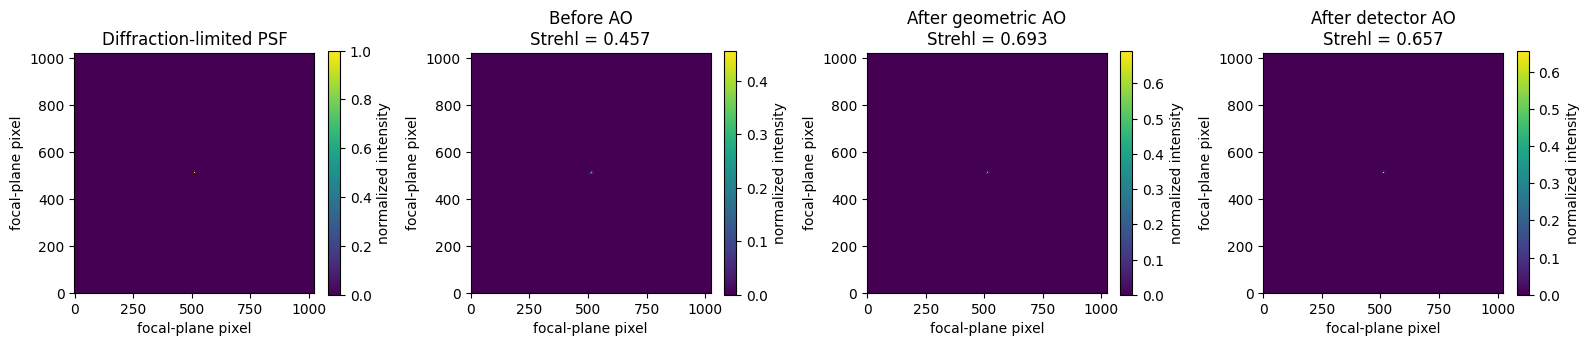

In [57]:
# ------------------------------------------------------------
# Plot PSFs on linear scale
# normalized by ideal diffraction-limited PSF peak
# ------------------------------------------------------------

ideal_peak = np.nanmax(psf_ideal)

if psf_after_geo is not None:
    psf_items = [
        (psf_ideal, "Diffraction-limited PSF"),
        (psf_before, f"Before AO\nStrehl = {strehl_before:.3f}"),
        (psf_after_geo, f"After geometric AO\nStrehl = {strehl_after_geo:.3f}"),
        (psf_after_det, f"After detector AO\nStrehl = {strehl_after_det:.3f}"),
    ]
else:
    psf_items = [
        (psf_ideal, "Diffraction-limited PSF"),
        (psf_before, f"Before AO\nStrehl = {strehl_before:.3f}"),
        (psf_after_det, f"After detector AO\nStrehl = {strehl_after_det:.3f}"),
    ]

fig, axes = plt.subplots(1, len(psf_items), figsize=(4 * len(psf_items), 4))

if len(psf_items) == 1:
    axes = [axes]

for ax, (psf, title) in zip(axes, psf_items):
    im = ax.imshow(
        psf / ideal_peak,
        origin="lower",
        interpolation="nearest",
    )
    ax.set_title(title)
    ax.set_xlabel("focal-plane pixel")
    ax.set_ylabel("focal-plane pixel")
    plt.colorbar(im, ax=ax, fraction=0.046, label="normalized intensity")

plt.tight_layout()
plt.show()

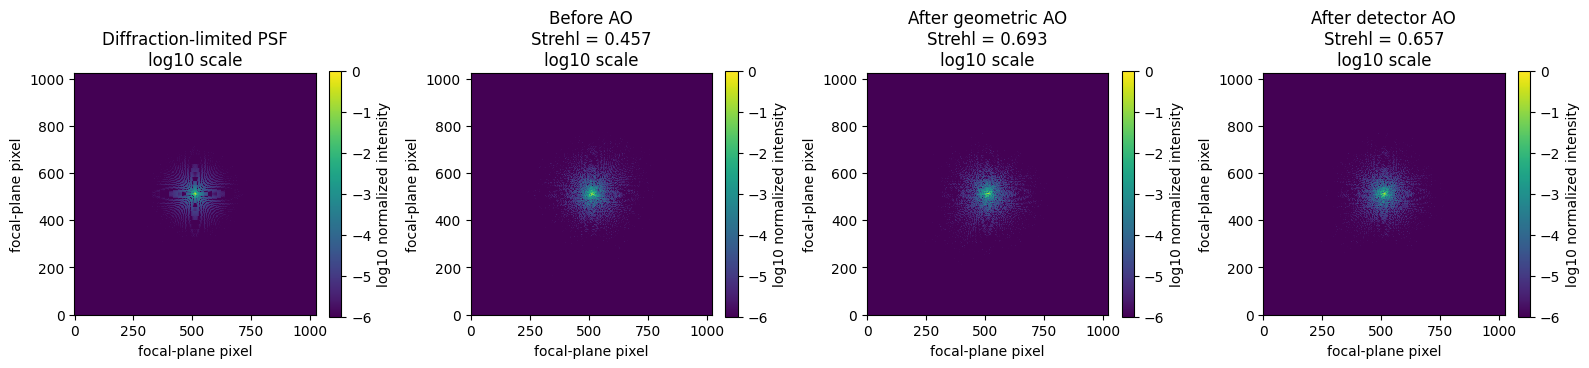

In [58]:
# ------------------------------------------------------------
# Plot PSFs on logarithmic scale
# ------------------------------------------------------------

fig, axes = plt.subplots(1, len(psf_items), figsize=(4 * len(psf_items), 4))

if len(psf_items) == 1:
    axes = [axes]

for ax, (psf, title) in zip(axes, psf_items):
    psf_norm = psf / ideal_peak
    psf_log = np.log10(np.maximum(psf_norm, 1e-10))

    im = ax.imshow(
        psf_log,
        origin="lower",
        interpolation="nearest",
        vmin=-6,
        vmax=0,
    )
    ax.set_title(title + "\nlog10 scale")
    ax.set_xlabel("focal-plane pixel")
    ax.set_ylabel("focal-plane pixel")
    plt.colorbar(im, ax=ax, fraction=0.046, label="log10 normalized intensity")

plt.tight_layout()
plt.show()

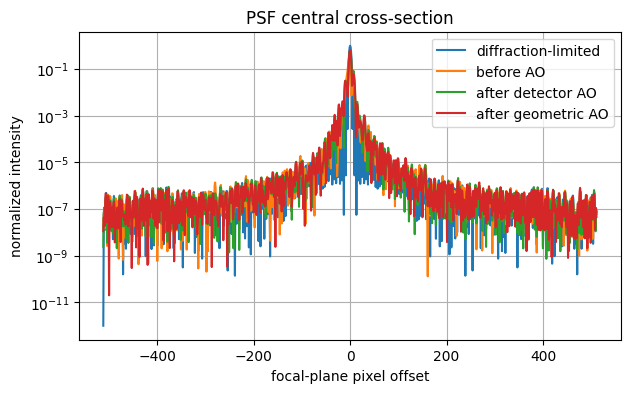

In [59]:
# ------------------------------------------------------------
# PSF central cross-section
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

for psf, label in [
    (psf_ideal, "diffraction-limited"),
    (psf_before, "before AO"),
    (psf_after_det, "after detector AO"),
]:
    center = psf.shape[0] // 2
    profile = psf[center, :] / ideal_peak
    x = np.arange(len(profile)) - center

    plt.semilogy(x, np.maximum(profile, 1e-12), label=label)

if psf_after_geo is not None:
    center = psf_after_geo.shape[0] // 2
    profile_geo = psf_after_geo[center, :] / ideal_peak
    x_geo = np.arange(len(profile_geo)) - center
    plt.semilogy(x_geo, np.maximum(profile_geo, 1e-12), label="after geometric AO")

plt.xlabel("focal-plane pixel offset")
plt.ylabel("normalized intensity")
plt.title("PSF central cross-section")
plt.grid(True, which="both")
plt.legend()
plt.show()

In [60]:
# ------------------------------------------------------------
# Compare measured Strehl with Maréchal approximation
# ------------------------------------------------------------

sigma_before = rms(W_atm, mask)
sigma_after_det = rms(W_corr_det, mask)

marechal_before = np.exp(-sigma_before**2)
marechal_after_det = np.exp(-sigma_after_det**2)

print("Maréchal approximation check")
print("---------------------------")
print(f"Before AO:")
print(f"  phase RMS:          {sigma_before:.4e} rad")
print(f"  measured Strehl:    {strehl_before:.4f}")
print(f"  exp(-sigma^2):      {marechal_before:.4f}")

print()
print(f"After detector AO:")
print(f"  phase RMS:          {sigma_after_det:.4e} rad")
print(f"  measured Strehl:    {strehl_after_det:.4f}")
print(f"  exp(-sigma^2):      {marechal_after_det:.4f}")

if strehl_after_geo is not None:
    sigma_after_geo = rms(W_corr_geo, mask)
    marechal_after_geo = np.exp(-sigma_after_geo**2)

    print()
    print(f"After geometric AO:")
    print(f"  phase RMS:          {sigma_after_geo:.4e} rad")
    print(f"  measured Strehl:    {strehl_after_geo:.4f}")
    print(f"  exp(-sigma^2):      {marechal_after_geo:.4f}")

Maréchal approximation check
---------------------------
Before AO:
  phase RMS:          9.9992e-01 rad
  measured Strehl:    0.4567
  exp(-sigma^2):      0.3679

After detector AO:
  phase RMS:          6.4308e-01 rad
  measured Strehl:    0.6570
  exp(-sigma^2):      0.6613

After geometric AO:
  phase RMS:          6.7236e-01 rad
  measured Strehl:    0.6930
  exp(-sigma^2):      0.6363


### PSF and Strehl after detector-level AO correction

This section converts the reconstructed residual wavefront into image-plane performance metrics.

The detector-level AO correction reduces the phase RMS of the incoming atmospheric wavefront. This leads to a sharper PSF core and a higher Strehl ratio. The comparison with the diffraction-limited PSF shows how close the corrected image is to the ideal telescope response.

The geometric SH-WFS reconstruction should be interpreted as an idealized upper-performance baseline. The detector-level reconstruction includes additional degradation from spot formation, detector sampling, photon noise, read noise, background noise, centroid bias, and response-matrix conditioning.

The Maréchal approximation, $$S \approx \exp(-\sigma_\phi^2)$$, provides a useful consistency check between residual phase RMS and Strehl ratio when the residual phase is not too large.

## Summary and interpretation

This notebook demonstrates an end-to-end geometric Shack-Hartmann wavefront sensing and modal reconstruction pipeline. A known low-order Zernike-like wavefront is first used as a sanity check. The reconstruction recovers the injected modal coefficients with negligible residual error, confirming that the slope measurement, response matrix construction, least-squares reconstruction, and wavefront synthesis are internally consistent.

The same pipeline is then applied to random atmospheric phase screens. Since the reconstruction basis contains only a limited set of low-order modes, the correction removes mainly the large-scale aberration components. The residual wavefront error remains significant because high-spatial-frequency atmospheric structures cannot be represented by the low-order modal basis. This demonstrates the role of modal truncation error in low-order AO correction.

The lenslet-number scan shows that increasing the number of Shack-Hartmann sub-apertures does not automatically lead to a monotonic decrease in residual RMS when the reconstructed modal basis is fixed. More lenslets provide finer slope sampling, but the correction is still limited by the number and type of reconstructed modes. A more complete sampling-versus-mode-order trade-off is studied in the later heatmap notebook.

The PSF and Strehl-ratio analysis connects the wavefront reconstruction to image quality. The simulated Strehl ratio improves after low-order correction, showing that the reduction in wavefront RMS also leads to a more concentrated focal-plane PSF.

Overall, this notebook serves as the baseline demonstration of the SH-WFS reconstruction pipeline. It validates the basic modal reconstruction method and motivates the later parameter studies on Zernike order, lenslet sampling, measurement noise, and regularization.